In [1]:
#Importing the basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

#Importing libraries necessary to train the model
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler #For normalisation of continuous data
from sklearn.preprocessing import OneHotEncoder #For one-hot encoding of host sex, continent and presence/absence of genes
from sklearn.preprocessing import LabelEncoder #For encoding the phenotype
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression #Baseline model
from sklearn.metrics import (
    classification_report, roc_curve, auc, precision_recall_curve, 
    average_precision_score, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, brier_score_loss, silhouette_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from imblearn.pipeline import Pipeline, make_pipeline
from imblearn.over_sampling import SMOTENC

from probatus.feature_elimination import EarlyStoppingShapRFECV

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import lightgbm
import xgboost as xgb
from xgboost import XGBClassifier

import seaborn as sns

from scipy.stats import spearmanr

import shap

import warnings
warnings.filterwarnings("ignore")

/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading the dataset
data = pd.read_excel("../data/final_dataset.xlsx",
                     sheet_name="Sheet1")
df = data.copy()

#Moving the Label column [Phenotype] to the end of the dataset
temp_cols = df.columns.tolist()
index = df.columns.get_loc("Phenotype")
new_cols = temp_cols[0:index] + temp_cols[index+1:] + temp_cols[index:index+1]
df = df[new_cols]

#Formatting the dataset
df['Continent'] = df['Continent'].replace('America','South America')
df['Phenotype'] = df['Phenotype'].replace({'Gastric cancer ' : 'Gastric cancer', 'Non-gastric cancer ' : 'Non-gastric cancer', 'non-gastric cancer ' : 'Non-gastric cancer' })
df['Sex'] = df['Sex'].str.title()
df.drop(df.index[(df['Sex'] == 'Not Applicable')],axis=0,inplace=True)

In [3]:
# Geographical distribution of the samples
continent_counts = df['Continent'].value_counts()
continent_counts

Continent
Europe           870
North America    282
South America    115
Asia              95
Name: count, dtype: int64

In [4]:
# X, y = df.iloc[:,1:-1], df.iloc[:,-1] #Splitting the dataframe into Features and Labels
X = df.drop(columns=['Genome_ID', 'Source', 'Phenotype'], axis=1) #Dropping Isolate_ID and Phenotype columns from the feature set
y = df['Phenotype']

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=26) #Splitting the dataframe into 80% training and 20% test set through StratifiedShuffleSplit
for train_index,test_index in sss.split(X,y):
  X_train_set = X.iloc[train_index]
  y_train_set = y.iloc[train_index]
  X_test_set = X.iloc[test_index]
  y_test_set = y.iloc[test_index]

In [5]:
# Check continent distribution
print("Train set continent distribution:")
print(df.iloc[train_index]['Continent'].value_counts())
print("\nTest set continent distribution:")
print(df.iloc[test_index]['Continent'].value_counts())

Train set continent distribution:
Continent
Europe           701
North America    221
South America     90
Asia              77
Name: count, dtype: int64

Test set continent distribution:
Continent
Europe           169
North America     61
South America     25
Asia              18
Name: count, dtype: int64


In [6]:
### Preprocessing the training set

le = LabelEncoder() # Label encoding the Labels in the training set
scaler = MinMaxScaler() # Normalising the continuous data in the training set
encoder = OneHotEncoder(sparse_output=False, handle_unknown="error") # One-hot encoding the categorical data in the training set

y_train_set_encoded = le.fit_transform(y_train_set) # Encoding the labels

numeric_cols = X_train_set.select_dtypes(include=['int64', 'float64']).columns # Selecting the numerical columns
X_train_set[numeric_cols] = scaler.fit_transform(X_train_set[numeric_cols]) # Applying MinMaxScaler only to the numeric columns

X_train_set.loc[:, "homB":"vacAs1m1"] = X_train_set.loc[:, "homB":"vacAs1m1"].astype('object') # Converting these columns to object type
categorical_columns = X_train_set.select_dtypes(include=['object']).columns.tolist() # Selecting the categorical columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown="error") # One-hot encoding the categorical columns
one_hot_encoded = encoder.fit_transform(X_train_set[categorical_columns]) 
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns),
                          index=X_train_set.index) # Creating a DataFrame from the one-hot encoded data

X_train_set_encoded = pd.concat([X_train_set, one_hot_df], axis=1) # Concatenating the one-hot encoded data with the original data

X_train_set_encoded = X_train_set_encoded.drop(categorical_columns, axis=1) # Dropping the original categorical columns
X_train_set_encoded.loc[:, "Sex_Female":"vacAs1m1_1.0"] = X_train_set_encoded.loc[:, "Sex_Female":"vacAs1m1_1.0"].astype('category') # Converting the one-hot encoded columns to category type

In [7]:
### Preprocessing the test set

y_test_set_encoded = le.transform(y_test_set)

X_test_set_unnorm = X_test_set.copy()

numeric_cols_test = X_test_set.select_dtypes(include=['int64', 'float64']).columns # Selecting the numerical columns
X_test_set[numeric_cols_test] = scaler.transform(X_test_set[numeric_cols_test]) # Applying MinMaxScaler only to numeric columns

X_test_set.loc[:, "homB":"vacAs1m1"] = X_test_set.loc[:, "homB":"vacAs1m1"].astype('object') # Converting these columns to object type
categorical_columns_test = X_test_set.select_dtypes(include=['object']).columns.tolist() # Selecting the categorical columns

one_hot_encoded_test = encoder.transform(X_test_set[categorical_columns_test]) # One-hot encoding the categorical columns

one_hot_df_test = pd.DataFrame(one_hot_encoded_test, columns=encoder.get_feature_names_out(categorical_columns_test),
                          index=X_test_set.index) # Creating a DataFrame from the one-hot encoded data

X_test_set_encoded = pd.concat([X_test_set, one_hot_df_test], axis=1) # Concatenating the one-hot encoded data with the original data

X_test_set_encoded = X_test_set_encoded.drop(categorical_columns_test, axis=1) # Dropping the original categorical columns
X_test_set_encoded.loc[:, "Sex_Female":"vacAs1m1_1.0"] = X_test_set_encoded.loc[:, "Sex_Female":"vacAs1m1_1.0"].astype('category') # Converting the one-hot encoded columns to category type

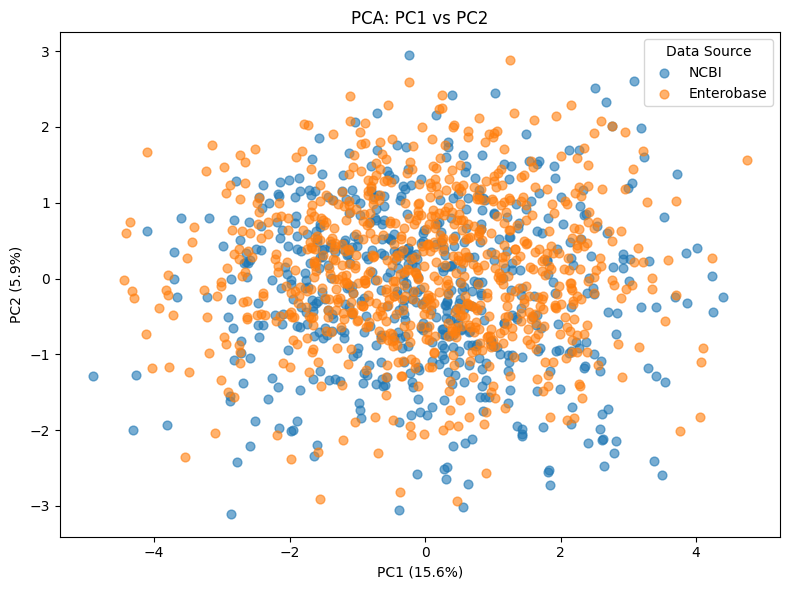

In [8]:
# PCA Analysis for identification of Batch Effects

from sklearn.decomposition import PCA

metadata = df[['Source', 'Phenotype']].copy()

X_all_encoded = pd.concat([X_train_set_encoded, X_test_set_encoded], axis=0)

metadata_all = metadata.loc[X_all_encoded.index]

X_all_numeric = X_all_encoded.astype(float)

pca = PCA(n_components=3)
pca_coords = pca.fit_transform(X_all_numeric)

pairs = [(0, 1)]

for i, j in pairs:
    plt.figure(figsize=(8, 6))
    for source in metadata_all['Source'].unique():
        mask = metadata_all['Source'] == source
        plt.scatter(
            pca_coords[mask, i],
            pca_coords[mask, j],
            label=source,
            alpha=0.6,
            s=40
        )

    plt.xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
    plt.ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
    plt.title(f'PCA: PC{i+1} vs PC{j+1}')
    plt.legend(title='Data Source')
    plt.tight_layout()
    plt.savefig(f'../results/2025-12-24_PCA_PC{i+1}_vs_PC{j+1}_by_source.png', dpi=600)
    plt.show()

In [9]:
# Silhouette score for Source
source_labels = (metadata_all['Source'] == 'NCBI').astype(int)
silhouette_source = silhouette_score(pca_coords, source_labels)

print(f"Silhouette score (Source): {silhouette_source:.3f}")

# Create score
score = pd.DataFrame({
    'Variable': ['Data Source'],
    'Silhouette Score': [silhouette_source]
})
print(score)

Silhouette score (Source): 0.008
      Variable  Silhouette Score
0  Data Source          0.008241


In [10]:
# Cross-validation splitter
ss = StratifiedShuffleSplit(n_splits=10, random_state=26)

In [11]:
# Bayesian Optimization and Feature Elimination

model_bayes = lightgbm.LGBMClassifier(max_depth=5, class_weight="balanced") # Model for Bayesian optimization

param_grid_bayes = {                 # Hyperparameter grid for Bayesian optimization
    "n_estimators": [5, 7, 10],
    "num_leaves": [3, 5, 7, 10],
}

search_bayes = BayesSearchCV(       # Bayesian optimization using scikit-optimize
    estimator=model_bayes,
    search_spaces=param_grid_bayes,
    verbose=0,
    random_state=26
)

# Create the EarlyStoppingShapRFECV object with early stopping parameters
shap_elimination_bayes = EarlyStoppingShapRFECV(
    model=search_bayes,           # hyperparameter tuning wrapper
    step=0.2,                     # proportion or number of features to remove per iteration
    cv=ss,                        # cross-validation splitter
    scoring='recall',             # evaluation metric used for CV
    eval_metric='recall',         # early stopping evaluation metric
    early_stopping_rounds=30,     # stop if no improvement is seen for 30 rounds
    n_jobs=-1,
    verbose=-1,
    random_state=26
)

# Run feature selection
report_bayes = shap_elimination_bayes.fit_compute(X_train_set_encoded, y_train_set_encoded)

best_features_bayes = shap_elimination_bayes.get_reduced_features_set(num_features="best") # Get the best features

final_features_set_bayes = shap_elimination_bayes.get_reduced_features_set(num_features=len(best_features_bayes)) # Get the final features set

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 605, number of negative: 266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 94118
[LightGBM] [Info] Number of data points in the train set: 871, number of used features: 498
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 605, number of negative: 266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 94087
[LightGBM] [Info] Number of data points in the train set: 871, number of used features

In [12]:
# Subsetting the training and test sets to the final features set
X_train_reduced = X_train_set_encoded[final_features_set_bayes] # Subset the training set to the final features set
X_test_reduced = X_test_set_encoded[final_features_set_bayes] # Subset the test set to the final features set

categorical_features_subset = X_train_reduced.select_dtypes(include=['category']).columns # Selecting the categorical features from the reduced training set
categorical_indices_subset = [X_train_reduced.columns.get_loc(col) for col in categorical_features_subset] # Getting the indices of the categorical features for SMOTENC

In [13]:
# Logistic Regression model training

lr_pipeline = make_pipeline(SMOTENC(categorical_features=categorical_indices_subset,
                                    random_state=26),
                             LogisticRegression(random_state=26)) # Makes a pipeline with SMOTENC and Logistic Regression

lr_pipeline.fit(X_train_reduced, y_train_set_encoded) # Fitting the pipeline to the full training set

Pipeline(steps=[('smotenc',
                 SMOTENC(categorical_features=[92], random_state=26)),
                ('logisticregression', LogisticRegression(random_state=26))])

In [14]:
# XGBoost Classifier training with Bayesian Optimization

xgb_pipeline = Pipeline([
    ('smote', SMOTENC(categorical_features=categorical_indices_subset, random_state=26)),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        enable_categorical=True,
        eval_metric='logloss',
        random_state=26
    ))
])


xgb_search_space = {                      
    'classifier__n_estimators': Integer(50, 1000),
    'classifier__max_depth': Integer(3, 7),
    'classifier__learning_rate': Real(0.01, 0.1),
    'classifier__subsample': Real(0.5, 1),
    'classifier__colsample_bytree': Real(0.5, 1),
    'classifier__min_child_weight': Integer(1, 10),
    'classifier__gamma': Real(0, 5),
    'classifier__reg_alpha': Real(1e-9, 10.0, prior='log-uniform'),
    'classifier__reg_lambda': Real(1e-9, 10.0, prior='log-uniform'),
}


xgb_bayes_search = BayesSearchCV(      # Bayesian optimization using scikit-optimize
    estimator=xgb_pipeline,
    search_spaces=xgb_search_space,
    scoring='recall',  # Using F1 score as the evaluation metric
    cv=ss,
    n_iter=60,
    n_points=2,
    n_jobs=2,
    verbose=2,
    random_state=26
)


xgb_bayes_search.fit(X_train_reduced, y_train_set_encoded) # Fit the XGBClassifier model on the reduced training set

xgb_calibrated_model = CalibratedClassifierCV(xgb_bayes_search.best_estimator_, method='sigmoid', cv=ss) # Calibrating the model using the best estimator from Bayesian optimization
xgb_calibrated_model.fit(X_train_reduced, y_train_set_encoded)

Exception ignored in: <function ResourceTracker.__del__ at 0x7172291944a0>
Traceback (most recent call last):
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7933152384a0>
Traceback (most recent call last):
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProc

Fitting 10 folds for each of 2 candidates, totalling 20 fits
[CV] END classifier__colsample_bytree=0.8710253864103497, classifier__gamma=4.937741895069575, classifier__learning_rate=0.03328017103854301, classifier__max_depth=4, classifier__min_child_weight=6, classifier__n_estimators=970, classifier__reg_alpha=0.00018075619344602056, classifier__reg_lambda=0.00016473374731881883, classifier__subsample=0.7273233990541943; total time=   1.2s
[CV] END classifier__colsample_bytree=0.8710253864103497, classifier__gamma=4.937741895069575, classifier__learning_rate=0.03328017103854301, classifier__max_depth=4, classifier__min_child_weight=6, classifier__n_estimators=970, classifier__reg_alpha=0.00018075619344602056, classifier__reg_lambda=0.00016473374731881883, classifier__subsample=0.7273233990541943; total time=   1.4s
[CV] END classifier__colsample_bytree=0.8710253864103497, classifier__gamma=4.937741895069575, classifier__learning_rate=0.03328017103854301, classifier__max_depth=4, classi

CalibratedClassifierCV(cv=StratifiedShuffleSplit(n_splits=10, random_state=26, test_size=None,
            train_size=None),
                       estimator=Pipeline(steps=[('smote',
                                                  SMOTENC(categorical_features=[92],
                                                          random_state=26)),
                                                 ('classifier',
                                                  XGBClassifier(base_score=None,
                                                                booster=None,
                                                                callbacks=None,
                                                                colsample_bylevel=None,
                                                                colsample_bynode=None,
                                                                colsample_bytree=1.0,
                                                                device=None,
                                                                earl...
                                                                gamma=0.0,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.027929298857299313,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=7,
                                                                max_leaves=None,
                                                                min_child_weight=1,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=1000,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [15]:
# Random Forest training with Bayesian Optimization

rf_pipeline = Pipeline([('smotenc', SMOTENC(categorical_features=categorical_indices_subset, random_state=26)),
    ('classifier_rf', RandomForestClassifier(random_state=26))
])

params_rf_bayes = {
    'classifier_rf__n_estimators': Integer(50, 2000),
    'classifier_rf__criterion': Categorical(['gini', 'entropy', 'log_loss']),
    'classifier_rf__max_depth': Integer(3, 10),
    'classifier_rf__min_samples_split': Integer(2, 10),
    'classifier_rf__min_samples_leaf': Integer(1, 10),
    'classifier_rf__bootstrap': Categorical([True, False]),
    'classifier_rf__ccp_alpha': Real(1e-6, 0.01, prior='log-uniform'),
}

bayes_search_rf = BayesSearchCV(
    estimator=rf_pipeline,
    search_spaces=params_rf_bayes,
    scoring='recall',
    cv=ss,
    n_iter=60,
    n_points=2,
    n_jobs=2,
    verbose=2,
    random_state=26
)
# Fit the model
bayes_search_rf.fit(X_train_reduced, y_train_set_encoded)


rf_calibrated_model = CalibratedClassifierCV(bayes_search_rf.best_estimator_, method='sigmoid', cv=ss)
rf_calibrated_model.fit(X_train_reduced, y_train_set_encoded)

Fitting 10 folds for each of 2 candidates, totalling 20 fits
[CV] END classifier_rf__bootstrap=False, classifier_rf__ccp_alpha=0.008916481566215747, classifier_rf__criterion=gini, classifier_rf__max_depth=5, classifier_rf__min_samples_leaf=6, classifier_rf__min_samples_split=10, classifier_rf__n_estimators=1075; total time=   8.6s
[CV] END classifier_rf__bootstrap=False, classifier_rf__ccp_alpha=0.008916481566215747, classifier_rf__criterion=gini, classifier_rf__max_depth=5, classifier_rf__min_samples_leaf=6, classifier_rf__min_samples_split=10, classifier_rf__n_estimators=1075; total time=   8.6s
[CV] END classifier_rf__bootstrap=False, classifier_rf__ccp_alpha=0.008916481566215747, classifier_rf__criterion=gini, classifier_rf__max_depth=5, classifier_rf__min_samples_leaf=6, classifier_rf__min_samples_split=10, classifier_rf__n_estimators=1075; total time=   8.4s
[CV] END classifier_rf__bootstrap=False, classifier_rf__ccp_alpha=0.008916481566215747, classifier_rf__criterion=gini, clas

CalibratedClassifierCV(cv=StratifiedShuffleSplit(n_splits=10, random_state=26, test_size=None,
            train_size=None),
                       estimator=Pipeline(steps=[('smotenc',
                                                  SMOTENC(categorical_features=[92],
                                                          random_state=26)),
                                                 ('classifier_rf',
                                                  RandomForestClassifier(bootstrap=False,
                                                                         ccp_alpha=8.863227160496232e-06,
                                                                         max_depth=10,
                                                                         min_samples_split=3,
                                                                         n_estimators=955,
                                                                         random_state=26))]))

In [ ]:
# Model Evaluation: Stratified by Continent

plt.rcParams.update({           
    'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'figure.dpi': 1200, 'savefig.dpi': 1200
})

def get_class_info(le, pos_class="Gastric cancer"):
    """Figure out which label is which class"""
    mapping = {name: i for i, name in enumerate(le.classes_)}
    neg_class = [k for k in mapping.keys() if k != pos_class][0]
    
    return {
        'pos_name': pos_class, 'pos_label': mapping[pos_class],
        'neg_name': neg_class, 'neg_label': mapping[neg_class],
        'mapping': mapping
    }

def bootstrap_ci(y_true, y_pred, y_prob, metric_func, n=1000):
    """Get confidence intervals via bootstrap"""
    np.random.seed(26)  # reproducibility
    scores = []
    
    for _ in range(n):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        
        # Skip if only one class in bootstrap sample
        if len(np.unique(y_true[idx])) < 2:
            continue
            
        try:
            if y_prob is not None:
                score = metric_func(y_true[idx], y_prob[idx])
            else:
                score = metric_func(y_true[idx], y_pred[idx])
            scores.append(score)
        except:
            continue  # skip problematic samples
    
    if not scores:
        return {'mean': np.nan, 'ci_low': np.nan, 'ci_high': np.nan}
    
    scores = np.array(scores)
    return {
        'mean': np.mean(scores),
        'ci_low': np.percentile(scores, 2.5),
        'ci_high': np.percentile(scores, 97.5)
    }

def plot_calibration(y_test, y_prob_cal, y_prob_raw, class_info, title="Calibration"):
    """Before/after calibration plots with Brier Score and ECE"""
    pos_label = class_info['pos_label']
    y_true_binary = (y_test == pos_label).astype(int)
    
    # Helper function to calculate ECE
    def calculate_ece(y_true, y_prob, n_bins=10):
        """Calculate Expected Calibration Error"""
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        
        ece = 0.0
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            # Find predictions in this bin
            in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
            prop_in_bin = np.mean(in_bin)
            
            if prop_in_bin > 0:
                accuracy_in_bin = np.mean(y_true[in_bin])
                avg_confidence_in_bin = np.mean(y_prob[in_bin])
                ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        
        return ece
    
    # FIXED: Handle axes creation properly
    if y_prob_raw is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        axes = [ax]
    
    plot_idx = 0
    
    # Before calibration
    if y_prob_raw is not None:
        frac, pred = calibration_curve(y_true_binary, y_prob_raw[:, pos_label], n_bins=10)
        brier = brier_score_loss(y_true_binary, y_prob_raw[:, pos_label])
        ece = calculate_ece(y_true_binary, y_prob_raw[:, pos_label], n_bins=10)
        
        axes[plot_idx].plot(pred, frac, 's-', label=class_info['pos_name'], linewidth=2, markersize=6)
        axes[plot_idx].plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
        axes[plot_idx].set_title("Before Calibration", fontweight='bold')
        
        # Add metrics text box
        metrics_text = f'Brier Score: {brier:.3f}\nECE: {ece:.3f}'
        axes[plot_idx].text(0.02, 0.98, metrics_text, 
                           transform=axes[plot_idx].transAxes, va='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                           fontsize=9)
        axes[plot_idx].legend(loc='lower right')
        plot_idx += 1
    
    # After calibration
    frac, pred = calibration_curve(y_true_binary, y_prob_cal[:, pos_label], n_bins=10)
    brier = brier_score_loss(y_true_binary, y_prob_cal[:, pos_label])
    ece = calculate_ece(y_true_binary, y_prob_cal[:, pos_label], n_bins=10)
    
    axes[plot_idx].plot(pred, frac, 's-', label=class_info['pos_name'], linewidth=2, markersize=6)
    axes[plot_idx].plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
    axes[plot_idx].set_title("After Calibration" if y_prob_raw is not None else "Calibration", 
                            fontweight='bold')
    
    # Add metrics text box
    metrics_text = f'Brier Score: {brier:.3f}\nECE: {ece:.3f}'
    axes[plot_idx].text(0.02, 0.98, metrics_text, 
                       transform=axes[plot_idx].transAxes, va='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=9)
    axes[plot_idx].legend(loc='lower right')
    
    # Format all axes
    for ax in axes:
        ax.set_xlabel("Mean Predicted Probability", fontweight='bold')
        ax.set_ylabel("Fraction of Positives", fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
    
    plt.tight_layout()
    return fig

def create_metrics_table(y_test, y_pred, y_prob, class_info):
    """Create comprehensive metrics table with confidence intervals"""
    pos_label = class_info['pos_label']
    neg_label = class_info['neg_label']
    pos_name = class_info['pos_name']
    neg_name = class_info['neg_name']
    
    # Calculate metrics with CIs for both classes
    metrics_data = []
    
    # Per-class metrics
    for label, class_name in [(pos_label, pos_name), (neg_label, neg_name)]:
        # Precision
        prec_ci = bootstrap_ci(y_test, y_pred, None, 
                              lambda yt, yp: precision_score(yt, yp, pos_label=label, zero_division=0))
        # Recall (Sensitivity for pos class, Specificity calculation for neg class)
        rec_ci = bootstrap_ci(y_test, y_pred, None, 
                             lambda yt, yp: recall_score(yt, yp, pos_label=label, zero_division=0))
        # F1-Score
        f1_ci = bootstrap_ci(y_test, y_pred, None, 
                            lambda yt, yp: f1_score(yt, yp, pos_label=label, zero_division=0))
        
        # AUPRC for this class
        def ap_func_class(y_true, y_prob):
            return average_precision_score(y_true, y_prob, pos_label=label)
        
        ap_ci = bootstrap_ci(y_test, None, y_prob[:, label], ap_func_class)
        
        metrics_data.extend([
            {
                'Class': class_name,
                'Metric': 'Precision',
                'Value': prec_ci['mean'],
                'CI_Lower': prec_ci['ci_low'],
                'CI_Upper': prec_ci['ci_high'],
                'Final': f"{prec_ci['mean']:.3f} ({prec_ci['ci_low']:.3f}–{prec_ci['ci_high']:.3f})"
            },
            {
                'Class': class_name,
                'Metric': 'Recall',
                'Value': rec_ci['mean'],
                'CI_Lower': rec_ci['ci_low'],
                'CI_Upper': rec_ci['ci_high'],
                'Final': f"{rec_ci['mean']:.3f} ({rec_ci['ci_low']:.3f}–{rec_ci['ci_high']:.3f})"
            },
            {
                'Class': class_name,
                'Metric': 'F1-Score',
                'Value': f1_ci['mean'],
                'CI_Lower': f1_ci['ci_low'],
                'CI_Upper': f1_ci['ci_high'],
                'Final': f"{f1_ci['mean']:.3f} ({f1_ci['ci_low']:.3f}–{f1_ci['ci_high']:.3f})"
            },
            {
                'Class': class_name,
                'Metric': 'AUPRC',
                'Value': ap_ci['mean'],
                'CI_Lower': ap_ci['ci_low'],
                'CI_Upper': ap_ci['ci_high'],
                'Final': f"{ap_ci['mean']:.3f} ({ap_ci['ci_low']:.3f}–{ap_ci['ci_high']:.3f})"
            }
        ])
    
    # Overall metrics
    # Accuracy
    acc_ci = bootstrap_ci(y_test, y_pred, None, lambda yt, yp: accuracy_score(yt, yp))
    
    # AUC-ROC (for positive class)
    def auc_func(y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=pos_label)
        return auc(fpr, tpr)
    auc_ci = bootstrap_ci(y_test, None, y_prob[:, pos_label], auc_func)
    
    # Add overall metrics
    overall_metrics = [
        {
            'Class': 'Overall',
            'Metric': 'Accuracy',
            'Value': acc_ci['mean'],
            'CI_Lower': acc_ci['ci_low'],
            'CI_Upper': acc_ci['ci_high'],
            'Final': f"{acc_ci['mean']:.3f} ({acc_ci['ci_low']:.3f}–{acc_ci['ci_high']:.3f})"
        },
        {
            'Class': 'Overall',
            'Metric': 'AUC-ROC',
            'Value': auc_ci['mean'],
            'CI_Lower': auc_ci['ci_low'],
            'CI_Upper': auc_ci['ci_high'],
            'Final': f"{auc_ci['mean']:.3f} ({auc_ci['ci_low']:.3f}–{auc_ci['ci_high']:.3f})"
        }
    ]
    
    metrics_data.extend(overall_metrics)
    
    # Create DataFrame
    df = pd.DataFrame(metrics_data)
    
    return df

def evaluate_by_region_enhanced(model, X_test, y_test, le, continent_column='Continent', 
                                save_dir='../results', prefix='model'):
    """
    Enhanced evaluation with multi-continent visualizations in single 2x2 figure:
    - Combined ROC curves with CIs
    - Combined PR curves with CIs
    - Grouped bar chart (Precision, Recall, F1 for Gastric cancer)
    - Combined confusion matrix (Option C layout)
    
    Parameters:
    -----------
    model : trained model
        Calibrated model with predict/predict_proba methods
    X_test : DataFrame
        Test features (must include continent_column)
    y_test : array
        Encoded test labels
    le : LabelEncoder
        Label encoder for class names
    continent_column : str
        Name of the column containing continent information
    save_dir : str
        Directory to save results
    prefix : str
        Prefix for saved files
    
    Returns:
    --------
    dict with results_df and figure
    """
    
    os.makedirs(f"{save_dir}/figures", exist_ok=True)
    
    class_info = get_class_info(le)
    pos_label = class_info['pos_label']
    neg_label = class_info['neg_label']
    
    # Check if continent column exists
    if continent_column not in X_test.columns:
        print(f"Warning: '{continent_column}' column not found in X_test")
        print(f"Available columns: {X_test.columns.tolist()}")
        return None
    
    # Get unique continents and sort for consistency
    continents = sorted(X_test[continent_column].unique())
    print(f"\nFound {len(continents)} continents: {continents}")
    
    # Color palette for continents
    continent_colors = {
        continents[i]: plt.cm.Set1(i) for i in range(len(continents))
    }
    
    # Store results and plot data
    results = []
    
    valid_continents = []  # Track which continents have valid data
    
    for continent in continents:
        # Filter by continent
        continent_mask = X_test[continent_column] == continent
        X_test_cont = X_test[continent_mask]
        y_test_cont = y_test[continent_mask]
        
        n_samples = len(y_test_cont)
        n_cancer = (y_test_cont == pos_label).sum()
        n_noncancer = (y_test_cont == neg_label).sum()
        cancer_rate = n_cancer / n_samples if n_samples > 0 else 0
        
        print(f"\n{continent}: n={n_samples}, cancer={n_cancer}, non-cancer={n_noncancer} ({cancer_rate:.1%})")
        
        if n_samples < 10:
            print(f"  ⚠ Skipping {continent} - too few samples (n={n_samples})")
            continue
        
        if len(np.unique(y_test_cont)) < 2:
            print(f"  ⚠ Skipping {continent} - only one class present")
            continue
        
        # Get predictions (remove continent column)
        X_test_cont_features = X_test_cont.drop(columns=[continent_column])
        
        try:
            y_pred_cont = model.predict(X_test_cont_features)
            y_prob_cont = model.predict_proba(X_test_cont_features)
            
            # ROC curve data with CI
            fpr, tpr, _ = roc_curve(y_test_cont, y_prob_cont[:, pos_label], pos_label=pos_label)
            roc_auc = auc(fpr, tpr)
            
            def auc_func(y_true, y_prob):
                fpr_b, tpr_b, _ = roc_curve(y_true, y_prob, pos_label=pos_label)
                return auc(fpr_b, tpr_b)
            
            auc_ci = bootstrap_ci(y_test_cont, None, y_prob_cont[:, pos_label], auc_func)
            
            
            # PR curve data with CI
            prec, rec, _ = precision_recall_curve(y_test_cont, y_prob_cont[:, pos_label], 
                                                   pos_label=pos_label)
            
            def ap_func(y_true, y_prob):
                return average_precision_score(y_true, y_prob, pos_label=pos_label)
            
            ap_ci = bootstrap_ci(y_test_cont, None, y_prob_cont[:, pos_label], ap_func)
            
            
            # Metrics with CI (for Gastric cancer class only)
            prec_ci = bootstrap_ci(y_test_cont, y_pred_cont, None,
                                  lambda yt, yp: precision_score(yt, yp, pos_label=pos_label, zero_division=0))
            rec_ci = bootstrap_ci(y_test_cont, y_pred_cont, None,
                                 lambda yt, yp: recall_score(yt, yp, pos_label=pos_label, zero_division=0))
            f1_ci = bootstrap_ci(y_test_cont, y_pred_cont, None,
                                lambda yt, yp: f1_score(yt, yp, pos_label=pos_label, zero_division=0))
            
            
            valid_continents.append(continent)
            
            # Store summary results
            results.append({
                'Continent': continent,
                'N_samples': n_samples,
                'N_cancer': n_cancer,
                'N_noncancer': n_noncancer,
                'Cancer_rate': cancer_rate,
                'AUROC': auc_ci['mean'],
                'AUROC_CI_low': auc_ci['ci_low'],
                'AUROC_CI_high': auc_ci['ci_high'],
                'AUPRC': ap_ci['mean'],
                'AUPRC_CI_low': ap_ci['ci_low'],
                'AUPRC_CI_high': ap_ci['ci_high'],
                'Precision': prec_ci['mean'],
                'Precision_CI_low': prec_ci['ci_low'],
                'Precision_CI_high': prec_ci['ci_high'],
                'Recall': rec_ci['mean'],
                'Recall_CI_low': rec_ci['ci_low'],
                'Recall_CI_high': rec_ci['ci_high'],
                'F1': f1_ci['mean'],
                'F1_CI_low': f1_ci['ci_low'],
                'F1_CI_high': f1_ci['ci_high']
            })
            
        except Exception as e:
            print(f"  ⚠ Error processing {continent}: {e}")
            continue
    
    # Create results dataframe
    results_df = pd.DataFrame(results)
    
    if len(results_df) == 0:
        print("\n⚠ No valid results obtained")
        return None
    
    # Save to CSV
    results_df.round(3).to_csv(f"{save_dir}/{prefix}_continent_stratified.csv", index=False)
    print(f"\n✓ Saved: {save_dir}/{prefix}_continent_stratified.csv")
    
    
    
    # Print summary
    print("\n" + "="*70)
    print("Geographic Stratification Summary")
    print("="*70)
    print(results_df.to_string(index=False))
    print("="*70)
    
    return {
        'results_df': results_df
    }


X_test_with_continent = X_test_reduced.copy()
X_test_with_continent['Continent'] = X_test_set['Continent']  # From original test set

# Logistic Regression Evaluation by Continent
os.makedirs("../results/2025-12-24_LR/figures", exist_ok=True)
lr_continent_results = evaluate_by_region_enhanced(
    model=lr_pipeline,
    X_test=X_test_with_continent,  # Must include Continent column
    y_test=y_test_set_encoded,
    le=le,
    continent_column='Continent',
    save_dir="../results/2025-12-24_LR",
    prefix="LR"
)

# XGBoost Evaluation by Continent
os.makedirs("../results/2025-12-24_XGB/figures", exist_ok=True)
xgb_continent_results = evaluate_by_region_enhanced(
    model=xgb_calibrated_model,
    X_test=X_test_with_continent,  # Must include Continent column
    y_test=y_test_set_encoded,
    le=le,
    continent_column='Continent',
    save_dir="../results/2025-12-24_XGB",
    prefix="XGB"
)

# Random Forest Evaluation by Continent
os.makedirs("../results/2025-12-24_RF/figures", exist_ok=True)
rf_continent_results = evaluate_by_region_enhanced(
    model=rf_calibrated_model,
    X_test=X_test_with_continent,  # Must include Continent column
    y_test=y_test_set_encoded,
    le=le,
    continent_column='Continent',
    save_dir="../results/2025-12-24_RF",
    prefix="RF"
)


Found 4 continents: ['Asia', 'Europe', 'North America', 'South America']

Asia: n=18, cancer=0, non-cancer=18 (0.0%)
  ⚠ Skipping Asia - only one class present

Europe: n=169, cancer=53, non-cancer=116 (31.4%)

North America: n=61, cancer=17, non-cancer=44 (27.9%)

South America: n=25, cancer=13, non-cancer=12 (52.0%)

✓ Saved: ../results/2025-12-24_LR/LR_continent_stratified.csv

Geographic Stratification Summary
    Continent  N_samples  N_cancer  N_noncancer  Cancer_rate    AUROC  AUROC_CI_low  AUROC_CI_high    AUPRC  AUPRC_CI_low  AUPRC_CI_high  Precision  Precision_CI_low  Precision_CI_high   Recall  Recall_CI_low  Recall_CI_high       F1  F1_CI_low  F1_CI_high
       Europe        169        53          116     0.313609 0.865619      0.803187       0.923224 0.714898      0.584261       0.837019   0.644019          0.527778           0.753095 0.849080       0.745088        0.940000 0.730861   0.637168    0.812068
North America         61        17           44     0.278689 0.7419

Exception ignored in: <function ResourceTracker.__del__ at 0x7e4cadc2c4a0>
Traceback (most recent call last):
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7a55a77204a0>
Traceback (most recent call last):
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/micro/miniforge3/envs/shaprfecv/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProc


North America: n=61, cancer=17, non-cancer=44 (27.9%)

South America: n=25, cancer=13, non-cancer=12 (52.0%)

✓ Saved: ../results/2025-12-24_XGB/XGB_continent_stratified.csv

Geographic Stratification Summary
    Continent  N_samples  N_cancer  N_noncancer  Cancer_rate    AUROC  AUROC_CI_low  AUROC_CI_high    AUPRC  AUPRC_CI_low  AUPRC_CI_high  Precision  Precision_CI_low  Precision_CI_high   Recall  Recall_CI_low  Recall_CI_high       F1  F1_CI_low  F1_CI_high
       Europe        169        53          116     0.313609 0.980197      0.957909       0.995107 0.965373      0.926433       0.989781   0.905730          0.823477           0.981132 0.923380       0.846111        0.982143 0.913717   0.851832    0.961557
North America         61        17           44     0.278689 0.812944      0.697920       0.913106 0.582229      0.363547       0.805578   0.545485          0.262829           0.833333 0.417091       0.199762        0.666667 0.463581   0.230769    0.666667
South America      

In [19]:
# Model Calibration: Stratified by Continent

plt.rcParams.update({           
    'font.size': 12, 
    'axes.titlesize': 14, 
    'axes.labelsize': 12,
    'xtick.labelsize': 11, 
    'ytick.labelsize': 11, 
    'legend.fontsize': 11,
    'figure.dpi': 300, 
    'savefig.dpi': 300
})

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def plot_calibration_curves_by_continent(y_test, y_prob_before, y_prob_after, 
                                         continent_col, pos_label=0,
                                         model_name="Model", save_path=None):
    """
    Plot calibration curves stratified by continent
    
    Parameters:
    -----------
    y_test : array
        True labels (encoded)
    y_prob_before : array or None
        Predicted probabilities BEFORE calibration (shape: n_samples, n_classes)
        Set to None for Logistic Regression (no before/after)
    y_prob_after : array
        Predicted probabilities AFTER calibration (shape: n_samples, n_classes)
    continent_col : pandas Series
        Continent labels for each sample
    pos_label : int
        Label for positive class (gastric cancer)
    model_name : str
        Name of model for title
    save_path : str or None
        Path to save figure (if None, displays only)
    """
    
    # Get unique continents (exclude Asia if needed due to class imbalance)
    continents = sorted(continent_col.unique())
    valid_continents = []
    
    # Check which continents have both classes
    for continent in continents:
        mask = continent_col == continent
        y_cont = y_test[mask]
        if len(np.unique(y_cont)) >= 2 and len(y_cont) >= 10:
            valid_continents.append(continent)
        else:
            print(f"Skipping {continent}: insufficient data or only one class")
    
    n_continents = len(valid_continents)
    
    if n_continents == 0:
        print("No valid continents for calibration analysis")
        return
    
    # Determine layout based on whether we have before/after
    if y_prob_before is not None:
        # Before and After: 2 columns
        fig, axes = plt.subplots(n_continents, 2, figsize=(12, 4.5*n_continents))
        if n_continents == 1:
            axes = axes.reshape(1, -1)
    else:
        # Only After (Logistic Regression): 1 column
        fig, axes = plt.subplots(n_continents, 1, figsize=(6, 4.5*n_continents))
        if n_continents == 1:
            axes = [axes]
        else:
            axes = axes.reshape(-1, 1)
    
    y_true_binary = (y_test == pos_label).astype(int)
    
    for i, continent in enumerate(valid_continents):
        mask = continent_col == continent
        y_true_cont = y_true_binary[mask]
        n_samples = mask.sum()
        n_cancer = y_true_cont.sum()
        n_noncancer = len(y_true_cont) - n_cancer
        
        # BEFORE calibration (if applicable)
        if y_prob_before is not None:
            ax_before = axes[i, 0]
            y_prob_cont_before = y_prob_before[mask, pos_label]
            
            frac, pred = calibration_curve(y_true_cont, y_prob_cont_before, n_bins=5)
            brier = brier_score_loss(y_true_cont, y_prob_cont_before)
            ece = calculate_ece(y_true_cont, y_prob_cont_before, n_bins=5)
            
            ax_before.plot(pred, frac, 's-', label='Gastric cancer', 
                          linewidth=2, markersize=8, color='#1f77b4')
            ax_before.plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
            ax_before.set_title(f"{continent} - Before Calibration\n"
                               f"n={n_samples} (GC={n_cancer}, Non-GC={n_noncancer})", 
                               fontweight='bold')
            
            metrics_text = f'Brier: {brier:.3f}\nECE: {ece:.3f}'
            ax_before.text(0.02, 0.98, metrics_text, 
                          transform=ax_before.transAxes, va='top',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                          fontsize=10)
            ax_before.legend(loc='lower right')
            ax_before.set_xlabel("Mean Predicted Probability", fontweight='bold')
            ax_before.set_ylabel("Fraction of Positives", fontweight='bold')
            ax_before.grid(True, alpha=0.3)
            ax_before.set_xlim([-0.05, 1.05])
            ax_before.set_ylim([-0.05, 1.05])
        
        # AFTER calibration (or only plot for LR)
        if y_prob_before is not None:
            ax_after = axes[i, 1]
        else:
            ax_after = axes[i] if n_continents == 1 else axes[i, 0]
        
        y_prob_cont_after = y_prob_after[mask, pos_label]
        
        frac, pred = calibration_curve(y_true_cont, y_prob_cont_after, n_bins=5)
        brier = brier_score_loss(y_true_cont, y_prob_cont_after)
        ece = calculate_ece(y_true_cont, y_prob_cont_after, n_bins=5)
        
        ax_after.plot(pred, frac, 's-', label='Gastric cancer', 
                     linewidth=2, markersize=8, color='#1f77b4')
        ax_after.plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
        
        title_suffix = "After Calibration" if y_prob_before is not None else "Calibration"
        ax_after.set_title(f"{continent} - {title_suffix}\n"
                          f"n={n_samples} (GC={n_cancer}, Non-GC={n_noncancer})", 
                          fontweight='bold')
        
        metrics_text = f'Brier: {brier:.3f}\nECE: {ece:.3f}'
        ax_after.text(0.02, 0.98, metrics_text, 
                     transform=ax_after.transAxes, va='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                     fontsize=10)
        ax_after.legend(loc='lower right')
        ax_after.set_xlabel("Mean Predicted Probability", fontweight='bold')
        ax_after.set_ylabel("Fraction of Positives", fontweight='bold')
        ax_after.grid(True, alpha=0.3)
        ax_after.set_xlim([-0.05, 1.05])
        ax_after.set_ylim([-0.05, 1.05])
    
    fig.suptitle(f"{model_name} - Geographic Calibration Analysis", 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    return fig


# LOGISTIC REGRESSION Calibration by Continent
os.makedirs("../results/2025-12-24_LR/figures", exist_ok=True)
fig_lr = plot_calibration_curves_by_continent(
    y_test=y_test_set_encoded,
    y_prob_before=None,  # LR doesn't need before/after
    y_prob_after=lr_pipeline.predict_proba(X_test_reduced),  # Calibrated probabilities
    continent_col=X_test_set['Continent'],
    pos_label=0,
    model_name="Logistic Regression",
    save_path="../results/2025-12-24_LR/figures/LR_calibration_by_continent.png"
)

# XGBOOST Calibration by Continent
os.makedirs("../results/2025-12-24_XGB/figures", exist_ok=True)
fig_xgb = plot_calibration_curves_by_continent(
    y_test=y_test_set_encoded,
    y_prob_before=xgb_bayes_search.predict_proba(X_test_reduced),  # Raw probabilities before calibration
    y_prob_after=xgb_calibrated_model.predict_proba(X_test_reduced),  # Calibrated probabilities
    continent_col=X_test_set['Continent'],
    pos_label=0,
    model_name="XGBoost",
    save_path="../results/2025-12-24_XGB/figures/XGB_calibration_by_continent.png"
)

# RANDOM FOREST Calibration by Continent
os.makedirs("../results/2025-12-24_RF/figures", exist_ok=True)
fig_rf = plot_calibration_curves_by_continent(
    y_test=y_test_set_encoded,
    y_prob_before=bayes_search_rf.predict_proba(X_test_reduced),  # Raw probabilities before calibration
    y_prob_after=rf_calibrated_model.predict_proba(X_test_reduced),  # Calibrated probabilities
    continent_col=X_test_set['Continent'],
    pos_label=0,
    model_name="Random Forest",
    save_path="../results/2025-12-24_RF/figures/RF_calibration_by_continent.png"
)

Skipping Asia: insufficient data or only one class
✓ Saved: ../results/2025-12-24_LR/figures/LR_calibration_by_continent.png
Skipping Asia: insufficient data or only one class
✓ Saved: ../results/2025-12-24_XGB/figures/XGB_calibration_by_continent.png
Skipping Asia: insufficient data or only one class
✓ Saved: ../results/2025-12-24_RF/figures/RF_calibration_by_continent.png


In [ ]:
# Model Evaluation: Full test set

plt.rcParams.update({           
    'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'figure.dpi': 1200, 'savefig.dpi': 1200
})

def get_class_info(le, pos_class="Gastric cancer"):
    """Figure out which label is which class"""
    mapping = {name: i for i, name in enumerate(le.classes_)}
    neg_class = [k for k in mapping.keys() if k != pos_class][0]
    
    return {
        'pos_name': pos_class, 'pos_label': mapping[pos_class],
        'neg_name': neg_class, 'neg_label': mapping[neg_class],
        'mapping': mapping
    }

def bootstrap_ci(y_true, y_pred, y_prob, metric_func, n=1000):
    """Get confidence intervals via bootstrap"""
    np.random.seed(26)  # reproducibility
    scores = []
    
    for _ in range(n):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        
        # Skip if only one class in bootstrap sample
        if len(np.unique(y_true[idx])) < 2:
            continue
            
        try:
            if y_prob is not None:
                score = metric_func(y_true[idx], y_prob[idx])
            else:
                score = metric_func(y_true[idx], y_pred[idx])
            scores.append(score)
        except:
            continue  # skip problematic samples
    
    if not scores:
        return {'mean': np.nan, 'ci_low': np.nan, 'ci_high': np.nan}
    
    scores = np.array(scores)
    return {
        'mean': np.mean(scores),
        'ci_low': np.percentile(scores, 2.5),
        'ci_high': np.percentile(scores, 97.5)
    }

def plot_calibration(y_test, y_prob_cal, y_prob_raw, class_info, title="Calibration"):
    """Before/after calibration plots with Brier Score and ECE"""
    
    pos_label = class_info['pos_label']
    y_true_binary = (y_test == pos_label).astype(int)
    
    # Helper function to calculate ECE
    def calculate_ece(y_true, y_prob, n_bins=10):
        """Calculate Expected Calibration Error"""
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        
        ece = 0.0
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            # Find predictions in this bin
            in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
            prop_in_bin = np.mean(in_bin)
            
            if prop_in_bin > 0:
                accuracy_in_bin = np.mean(y_true[in_bin])
                avg_confidence_in_bin = np.mean(y_prob[in_bin])
                ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        
        return ece
    
    # FIXED: Handle axes creation properly
    if y_prob_raw is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        axes = [ax]
    
    plot_idx = 0
    
    # Before calibration
    if y_prob_raw is not None:
        frac, pred = calibration_curve(y_true_binary, y_prob_raw[:, pos_label], n_bins=10)
        brier = brier_score_loss(y_true_binary, y_prob_raw[:, pos_label])
        ece = calculate_ece(y_true_binary, y_prob_raw[:, pos_label], n_bins=10)
        
        axes[plot_idx].plot(pred, frac, 's-', label=class_info['pos_name'], linewidth=2, markersize=6)
        axes[plot_idx].plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
        axes[plot_idx].set_title("Before Calibration", fontweight='bold')
        
        # Add metrics text box
        metrics_text = f'Brier Score: {brier:.3f}\nECE: {ece:.3f}'
        axes[plot_idx].text(0.02, 0.98, metrics_text, 
                           transform=axes[plot_idx].transAxes, va='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                           fontsize=9)
        axes[plot_idx].legend(loc='lower right')
        plot_idx += 1
    
    # After calibration
    frac, pred = calibration_curve(y_true_binary, y_prob_cal[:, pos_label], n_bins=10)
    brier = brier_score_loss(y_true_binary, y_prob_cal[:, pos_label])
    ece = calculate_ece(y_true_binary, y_prob_cal[:, pos_label], n_bins=10)
    
    axes[plot_idx].plot(pred, frac, 's-', label=class_info['pos_name'], linewidth=2, markersize=6)
    axes[plot_idx].plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
    axes[plot_idx].set_title("After Calibration" if y_prob_raw is not None else "Calibration", 
                            fontweight='bold')
    
    # Add metrics text box
    metrics_text = f'Brier Score: {brier:.3f}\nECE: {ece:.3f}'
    axes[plot_idx].text(0.02, 0.98, metrics_text, 
                       transform=axes[plot_idx].transAxes, va='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=9)
    axes[plot_idx].legend(loc='lower right')
    
    # Format all axes
    for ax in axes:
        ax.set_xlabel("Mean Predicted Probability", fontweight='bold')
        ax.set_ylabel("Fraction of Positives", fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
    
    plt.tight_layout()
    return fig

def create_metrics_table(y_test, y_pred, y_prob, class_info):
    """Create comprehensive metrics table with confidence intervals"""
    pos_label = class_info['pos_label']
    neg_label = class_info['neg_label']
    pos_name = class_info['pos_name']
    neg_name = class_info['neg_name']
    
    # Calculate metrics with CIs for both classes
    metrics_data = []
    
    # Per-class metrics
    for label, class_name in [(pos_label, pos_name), (neg_label, neg_name)]:
        # Precision
        prec_ci = bootstrap_ci(y_test, y_pred, None, 
                              lambda yt, yp: precision_score(yt, yp, pos_label=label, zero_division=0))
        # Recall (Sensitivity for pos class, Specificity calculation for neg class)
        rec_ci = bootstrap_ci(y_test, y_pred, None, 
                             lambda yt, yp: recall_score(yt, yp, pos_label=label, zero_division=0))
        # F1-Score
        f1_ci = bootstrap_ci(y_test, y_pred, None, 
                            lambda yt, yp: f1_score(yt, yp, pos_label=label, zero_division=0))
        
        # AUPRC for this class
        def ap_func_class(y_true, y_prob):
            return average_precision_score(y_true, y_prob, pos_label=label)
        
        ap_ci = bootstrap_ci(y_test, None, y_prob[:, label], ap_func_class)
        
        metrics_data.extend([
            {
                'Class': class_name,
                'Metric': 'Precision',
                'Value': prec_ci['mean'],
                'CI_Lower': prec_ci['ci_low'],
                'CI_Upper': prec_ci['ci_high'],
                'Final': f"{prec_ci['mean']:.3f} ({prec_ci['ci_low']:.3f}–{prec_ci['ci_high']:.3f})"
            },
            {
                'Class': class_name,
                'Metric': 'Recall',
                'Value': rec_ci['mean'],
                'CI_Lower': rec_ci['ci_low'],
                'CI_Upper': rec_ci['ci_high'],
                'Final': f"{rec_ci['mean']:.3f} ({rec_ci['ci_low']:.3f}–{rec_ci['ci_high']:.3f})"
            },
            {
                'Class': class_name,
                'Metric': 'F1-Score',
                'Value': f1_ci['mean'],
                'CI_Lower': f1_ci['ci_low'],
                'CI_Upper': f1_ci['ci_high'],
                'Final': f"{f1_ci['mean']:.3f} ({f1_ci['ci_low']:.3f}–{f1_ci['ci_high']:.3f})"
            },
            {
                'Class': class_name,
                'Metric': 'AUPRC',
                'Value': ap_ci['mean'],
                'CI_Lower': ap_ci['ci_low'],
                'CI_Upper': ap_ci['ci_high'],
                'Final': f"{ap_ci['mean']:.3f} ({ap_ci['ci_low']:.3f}–{ap_ci['ci_high']:.3f})"
            }
        ])
    
    # Overall metrics
    # Accuracy
    acc_ci = bootstrap_ci(y_test, y_pred, None, lambda yt, yp: accuracy_score(yt, yp))
    
    # AUC-ROC (for positive class)
    def auc_func(y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=pos_label)
        return auc(fpr, tpr)
    auc_ci = bootstrap_ci(y_test, None, y_prob[:, pos_label], auc_func)
    
    # Add overall metrics
    overall_metrics = [
        {
            'Class': 'Overall',
            'Metric': 'Accuracy',
            'Value': acc_ci['mean'],
            'CI_Lower': acc_ci['ci_low'],
            'CI_Upper': acc_ci['ci_high'],
            'Final': f"{acc_ci['mean']:.3f} ({acc_ci['ci_low']:.3f}–{acc_ci['ci_high']:.3f})"
        },
        {
            'Class': 'Overall',
            'Metric': 'AUC-ROC',
            'Value': auc_ci['mean'],
            'CI_Lower': auc_ci['ci_low'],
            'CI_Upper': auc_ci['ci_high'],
            'Final': f"{auc_ci['mean']:.3f} ({auc_ci['ci_low']:.3f}–{auc_ci['ci_high']:.3f})"
        }
    ]
    
    metrics_data.extend(overall_metrics)
    
    # Create DataFrame
    df = pd.DataFrame(metrics_data)
    
    return df

def evaluate_and_plot(model, X_test, y_test, le, save_dir, prefix, 
                      model_name="Model", raw_model=None):
    """
    Full evaluation pipeline:
    - Predictions
    - Bootstrap CIs
    - Metrics table
    - CSV outputs
    - 2x2 grid figure (ROC, PR, metrics, confusion matrix)
    - Calibration plot (separate)
    """
    os.makedirs(f"{save_dir}/figures", exist_ok=True)
    
    class_info = get_class_info(le)
    pos_label = class_info['pos_label']
    neg_label = class_info['neg_label']
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    y_prob_raw = raw_model.predict_proba(X_test) if raw_model else None
    
    y_test_orig = le.inverse_transform(y_test)
    y_pred_orig = le.inverse_transform(y_pred)
    report = classification_report(y_test_orig, y_pred_orig, output_dict=True)
    pd.DataFrame(report).T.to_csv(f"{save_dir}/{prefix}_report.csv")
    
    def auc_func(y_true, y_prob): return auc(*roc_curve(y_true, y_prob, pos_label=pos_label)[:2])
    def ap_func_pos(y_true, y_prob): return average_precision_score(y_true, y_prob, pos_label=pos_label)
    def ap_func_neg(y_true, y_prob): return average_precision_score(y_true, y_prob, pos_label=neg_label)
    
    auc_ci = bootstrap_ci(y_test, None, y_prob[:, pos_label], auc_func)
    ap_ci_pos = bootstrap_ci(y_test, None, y_prob[:, pos_label], ap_func_pos)
    ap_ci_neg = bootstrap_ci(y_test, None, y_prob[:, neg_label], ap_func_neg)
    
    metrics_table = create_metrics_table(y_test, y_pred, y_prob, class_info)
    metrics_table.to_csv(f"{save_dir}/{prefix}_detailed_metrics.csv", index=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    plt.subplots_adjust(hspace=0.7, wspace=0.7)

    fontsize_labels = 16   
    fontsize_ticks = 14    
    fontsize_legend = 14   
    fontsize_title = 18    
    
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, pos_label], pos_label=pos_label)
    axes[0,0].plot(fpr, tpr, 'r-', linewidth=2,
                   label=f"{class_info['pos_name']} - AUC = {auc_ci['mean']:.3f} "
                         f"(95% CI: {auc_ci['ci_low']:.3f}–{auc_ci['ci_high']:.3f})")
    axes[0,0].plot([0,1],[0,1],'k--', alpha=0.5)
    axes[0,0].set_xlabel("False Positive Rate", fontsize=fontsize_labels)
    axes[0,0].set_ylabel("True Positive Rate", fontsize=fontsize_labels)
    axes[0,0].tick_params(axis='both', which='major', labelsize=fontsize_ticks)
    axes[0,0].set_title("A. ROC Curve", fontsize=fontsize_title, fontweight='bold')
    axes[0,0].legend(fontsize=fontsize_legend)
    axes[0,0].grid(True, alpha=0.3)
    

    prec, rec, _ = precision_recall_curve(y_test, y_prob[:, pos_label], pos_label=pos_label)
    prec_neg, rec_neg, _ = precision_recall_curve(y_test, y_prob[:, neg_label], pos_label=neg_label)
    axes[0,1].plot(rec, prec, 'b-', linewidth=2,
                   label=f"{class_info['pos_name']} - AUPRC = {ap_ci_pos['mean']:.3f} "
                         f"(95% CI: {ap_ci_pos['ci_low']:.3f}–{ap_ci_pos['ci_high']:.3f})")
    axes[0,1].plot(rec_neg, prec_neg, 'g--', linewidth=2,
                   label=f"{class_info['neg_name']} - AUPRC = {ap_ci_neg['mean']:.3f} "
                         f"(95% CI: {ap_ci_neg['ci_low']:.3f}–{ap_ci_neg['ci_high']:.3f})")
    axes[0,1].set_xlabel("Recall", fontsize=fontsize_labels)
    axes[0,1].set_ylabel("Precision", fontsize=fontsize_labels)
    axes[0,1].set_title("B. Precision-Recall Curve", fontsize=fontsize_title, fontweight='bold')
    axes[0,1].tick_params(axis='both', which='major', labelsize=fontsize_ticks)
    axes[0,1].legend(fontsize=fontsize_legend)
    axes[0,1].grid(True, alpha=0.3)
    

    metrics = {}
    for label, name in [(pos_label, class_info['pos_name']), (neg_label, class_info['neg_name'])]:
        metrics[name] = {
            'Precision': bootstrap_ci(y_test, y_pred, None, lambda yt, yp: precision_score(yt, yp, pos_label=label, zero_division=0)),
            'Recall': bootstrap_ci(y_test, y_pred, None, lambda yt, yp: recall_score(yt, yp, pos_label=label, zero_division=0)),
            'F1-Score': bootstrap_ci(y_test, y_pred, None, lambda yt, yp: f1_score(yt, yp, pos_label=label, zero_division=0))
        }
    metric_names = ['Precision', 'Recall', 'F1-Score']
    class_names = list(metrics.keys())
    pos_means = [metrics[class_names[0]][m]['mean'] for m in metric_names]
    neg_means = [metrics[class_names[1]][m]['mean'] for m in metric_names]
    pos_errs = [(metrics[class_names[0]][m]['ci_high'] - metrics[class_names[0]][m]['ci_low'])/2 for m in metric_names]
    neg_errs = [(metrics[class_names[1]][m]['ci_high'] - metrics[class_names[1]][m]['ci_low'])/2 for m in metric_names]
    
    y_pos = np.arange(len(metric_names))
    width = 0.35
    axes[1,0].barh(y_pos - width/2, pos_means, width, xerr=pos_errs, label=class_names[0], color='#E31A1C', alpha=0.8, capsize=3, hatch='///')
    axes[1,0].barh(y_pos + width/2, neg_means, width, xerr=neg_errs, label=class_names[1], color='#1F78B4', alpha=0.8, capsize=3, hatch='...')
    
    for i in range(len(metric_names)):
        axes[1,0].text(pos_means[i]+pos_errs[i]+0.02, y_pos[i]-width/2, f'{pos_means[i]:.3f}', va='center', fontsize=14)
        axes[1,0].text(neg_means[i]+neg_errs[i]+0.02, y_pos[i]+width/2, f'{neg_means[i]:.3f}', va='center', fontsize=14)
    
    axes[1,0].set_yticks(y_pos)
    axes[1,0].set_yticklabels(metric_names)
    axes[1,0].set_xlabel("Score", fontsize=fontsize_labels)
    axes[1,0].set_title("C. Classification Metrics", fontsize=fontsize_title, fontweight='bold')
    axes[1,0].tick_params(axis='both', which='major', labelsize=fontsize_ticks)
    axes[1,0].legend(fontsize=fontsize_legend)
    axes[1,0].grid(True, alpha=0.3, axis='x')
    axes[1,0].set_xlim(0, 1.15)
    

    labels = [neg_label, pos_label]
    names = [class_info['neg_name'], class_info['pos_name']]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Calculate class totals
    class_totals = cm.sum(axis=1)  # Sum across rows (true labels)

    # Create labels with totals
    names_with_totals = [f"{names[i]}\n(n={class_totals[i]})" for i in range(len(names))]

    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=names, yticklabels=names_with_totals, ax=axes[1,1])

    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()/2 else 'black'
            axes[1,1].text(j+0.5, i+0.5, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)', 
                        ha='center', va='center', color=color, fontweight='bold', fontsize=14)

    axes[1,1].set_title("D. Confusion Matrix", fontsize=fontsize_title, fontweight='bold')
    axes[1,1].set_xlabel("Predicted Labels", fontsize=fontsize_labels)
    axes[1,1].set_ylabel("True Labels", fontsize=fontsize_labels)
    axes[1,1].tick_params(axis='both', which='major', labelsize=fontsize_ticks)

    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn)/cm.sum()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0

    # Add total sample size to the footer
    total_n = cm.sum()
    axes[1,1].text(0.5, -0.18, 
                f'Total n={total_n} | Accuracy: {acc:.3f} | Sensitivity: {sens:.3f} | Specificity: {spec:.3f}', 
                transform=axes[1,1].transAxes, ha='center', style='italic', fontsize=12)
    
    fig.suptitle(f"{model_name} Evaluation", fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    

    fig.savefig(f"{save_dir}/figures/{prefix}_2x2_grid.png", dpi=1200, bbox_inches='tight')
    fig.savefig(f"{save_dir}/figures/{prefix}_2x2_grid.pdf", bbox_inches='tight')
    plt.close(fig)
    

    fig_cal = plot_calibration(y_test, y_prob, y_prob_raw, class_info)
    fig_cal.savefig(f"{save_dir}/figures/{prefix}_calibration.png", dpi=1200, bbox_inches='tight')
    fig_cal.savefig(f"{save_dir}/figures/{prefix}_calibration.pdf", bbox_inches='tight')
    plt.close(fig_cal)
    

    return {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc': auc_ci,
        'auprc_pos': ap_ci_pos,
        'auprc_neg': ap_ci_neg,
        'metrics_table': metrics_table,
        'fig_grid': fig,
        'fig_calibration': fig_cal
    }

# LOGISTIC REGRESSION: Full Test Set Evaluation
os.makedirs("../results/2025-12-24_LR/figures", exist_ok=True)
evaluate_and_plot(
    model=lr_pipeline,         
    X_test=X_test_reduced,             
    y_test=y_test_set_encoded,         
    le=le,                             
    save_dir="../results/2025-12-24_LR",  
    prefix="LR",                        
    model_name="Logistic Regression",        
    raw_model=None          
)

# XGBOOST: Full Test Set Evaluation
os.makedirs("../results/2025-12-24_XGB/figures", exist_ok=True)
evaluate_and_plot(
    model=xgb_calibrated_model,        
    X_test=X_test_reduced,             
    y_test=y_test_set_encoded,         
    le=le,                             
    save_dir="../results/2025-12-24_XGB",  
    prefix="XGB",                       
    model_name="XGBoost",                   
    raw_model=xgb_bayes_search      
)

# RANDOM FOREST: Full Test Set Evaluation
os.makedirs("../results/2025-12-24_RF/figures", exist_ok=True)
evaluate_and_plot(
    model=rf_calibrated_model,        
    X_test=X_test_reduced,             
    y_test=y_test_set_encoded,         
    le=le,                             
    save_dir="../results/2025-12-24_RF",  
    prefix="RF",                       
    model_name="Random Forest",             
    raw_model=bayes_search_rf      
)

{'y_pred': array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
        0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 0, 1, 1, 1, 1, 1]),
 'y_prob': array([[0.17883903, 0.82116097],
        [0.0254248 , 

In [22]:
# Model Explanation with SHAP

def explain_model_with_shap_plots(
    pipeline, X_train, X_test, save_dir, classifier_step_name="classifier", 
    sample_idx=0, only_explain_gc=True
):
    """
    Generates SHAP global summary plot and SHAP waterfall plot for a specific sample.
    """
    # Set larger font sizes for all plots
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
    })

    os.makedirs(os.path.join(save_dir, "figures"), exist_ok=True)

    # Convert categorical variables to numeric
    X_train_num = X_train.copy()
    X_test_num = X_test.copy()
    
    for col in X_train_num.select_dtypes(include="category").columns:
        X_train_num[col] = X_train_num[col].cat.codes
        X_test_num[col] = X_test_num[col].cat.codes

    X_train_num = X_train_num.astype(float)
    X_test_num = X_test_num.astype(float)
    
    # Handle problematic values
    X_train_num = X_train_num.replace([np.inf, -np.inf], np.nan)
    X_test_num = X_test_num.replace([np.inf, -np.inf], np.nan)
    X_train_num = X_train_num.fillna(X_train_num.median())
    X_test_num = X_test_num.fillna(X_train_num.median())

    # Auto-detect classifier step
    if hasattr(pipeline, "named_steps"):  
        model_step_names = list(pipeline.named_steps.keys())
        classifier_step_name = model_step_names[-1]
        model = pipeline.named_steps[classifier_step_name]
    elif hasattr(pipeline, "estimator") and hasattr(pipeline.estimator, "named_steps"):  
        model_step_names = list(pipeline.estimator.named_steps.keys())
        classifier_step_name = model_step_names[-1]
        model = pipeline.estimator.named_steps[classifier_step_name]
    else:
        raise ValueError("Could not find classifier step in pipeline.")

    print(f"Using classifier: {classifier_step_name} ({type(model).__name__})")

    # Select appropriate SHAP explainer
    if isinstance(model, (RandomForestClassifier, xgb.XGBClassifier)):
        explainer = shap.TreeExplainer(model)
    elif isinstance(model, LogisticRegression):
        background_sample = shap.sample(X_train_num, 100)
        explainer = shap.LinearExplainer(model, background_sample)
    else:
        background_sample = shap.sample(X_train_num, 50)
        explainer = shap.PermutationExplainer(model.predict, background_sample)

    # Calculate SHAP values
    print("Computing SHAP values...")
    shap_values = explainer(X_test_num)

    if sample_idx >= len(X_test_num):
        sample_idx = 0
    
    sample_pred = pipeline.predict(X_test_num.iloc[[sample_idx]])[0]
    sample_probs = pipeline.predict_proba(X_test_num.iloc[[sample_idx]])[0]

    predicted_class = "Gastric cancer" if sample_pred == 0 else "Non-gastric cancer"
    print(f"Sample {sample_idx} predicted as: {predicted_class}")

    if only_explain_gc and sample_pred != 0:
        print(f"Skipping explanation: Sample not classified as gastric cancer.")
        return

    # Handle SHAP value formats and prepare data
    if hasattr(shap_values, 'values'):
        if shap_values.values.ndim == 3:
            values_for_bar = shap_values.values[:, :, 0]
            waterfall_values = shap_values.values[sample_idx, :, 0]
            expected_value = shap_values.base_values[sample_idx, 0]
        else:
            values_for_bar = shap_values.values
            waterfall_values = shap_values.values[sample_idx]
            expected_value = shap_values.base_values[sample_idx]
        feature_values = shap_values.data
    else:
        values_for_bar = shap_values
        waterfall_values = shap_values[sample_idx]
        expected_value = explainer.expected_value
        feature_values = X_test_num.values

    # Create SHAP explanation object for bar plot
    shap_explanation_for_bar = shap.Explanation(
        values=values_for_bar,
        base_values=expected_value,
        data=feature_values,
        feature_names=X_test_num.columns.tolist()
    )

    # Create explanation object for waterfall plot
    explanation_obj = shap.Explanation(
        values=waterfall_values,
        base_values=expected_value,
        data=X_test_num.iloc[sample_idx].values,
        feature_names=X_test_num.columns.tolist()
    )

    # Create combined plot with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(70, 40), gridspec_kw={'hspace': 0.8})
    
    # Global SHAP bar plot
    ax1.text(-0.02, 1.25, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top')
    shap.plots.bar(shap_explanation_for_bar, ax=ax1, show=False, max_display=10)
    ax1.set_title('Global Feature Importance', fontsize=16, fontweight='bold', pad=20)
    
    # Individual waterfall plot 
    ax2.text(-0.02, 1.4, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')
    plt.sca(ax2)
    shap.waterfall_plot(explanation_obj, show=False)
    ax2.set_title(f'Individual Prediction Explanation - Sample {sample_idx}', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout(pad=2.0)
    combined_path = os.path.join(save_dir, "figures", f"shap_combined_plots_sample_{sample_idx}.png")
    plt.savefig(combined_path, dpi=1200, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"Combined SHAP plots saved to: {combined_path}")


# Logistic Regression SHAP Explanations
explain_model_with_shap_plots(
    lr_pipeline, 
    X_train_reduced, 
    X_test_reduced, 
    "../results/2025-12-24_LR", 
    sample_idx=2,
    only_explain_gc=True
)
# XGBoost SHAP Explanations
explain_model_with_shap_plots(
    xgb_calibrated_model, 
    X_train_reduced, 
    X_test_reduced, 
    "../results/2025-12-24_XGB", 
    sample_idx=2,
    only_explain_gc=True
)

# Random Forest SHAP Explanations
explain_model_with_shap_plots(
    rf_calibrated_model, 
    X_train_reduced, 
    X_test_reduced, 
    "../results/2025-12-24_RF", 
    sample_idx=2,
    only_explain_gc=True
)

Using classifier: logisticregression (LogisticRegression)
Computing SHAP values...
Sample 2 predicted as: Gastric cancer
Combined SHAP plots saved to: ../results/2025-12-24_LR/figures/shap_combined_plots_sample_2.png
Using classifier: classifier (XGBClassifier)
Computing SHAP values...
Sample 2 predicted as: Gastric cancer
Combined SHAP plots saved to: ../results/2025-12-24_XGB/figures/shap_combined_plots_sample_2.png
Using classifier: classifier_rf (RandomForestClassifier)
Computing SHAP values...
Sample 2 predicted as: Gastric cancer
Combined SHAP plots saved to: ../results/2025-12-24_RF/figures/shap_combined_plots_sample_2.png


In [ ]:
# Feature Importance Table with SHAP

def create_shap_feature_importance_table(
    pipeline, X_train, X_test, save_dir, model_name="Model",
    classifier_step_name="classifier", top_n=10
):
    """
    Creates a quantitative table summarizing top N features by mean |SHAP| values.
    
    Parameters:
    -----------
    pipeline : sklearn pipeline or calibrated classifier
        Trained model pipeline
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    save_dir : str
        Directory to save the table
    model_name : str
        Name of the model for file naming
    classifier_step_name : str
        Name of classifier step in pipeline (auto-detected if not specified)
    top_n : int
        Number of top features to include in table
    
    Returns:
    --------
    pd.DataFrame : Table with feature importance metrics
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # Convert categorical variables to numeric
    X_train_num = X_train.copy()
    X_test_num = X_test.copy()
    
    for col in X_train_num.select_dtypes(include="category").columns:
        X_train_num[col] = X_train_num[col].cat.codes
        X_test_num[col] = X_test_num[col].cat.codes

    X_train_num = X_train_num.astype(float)
    X_test_num = X_test_num.astype(float)
    
    # Handle problematic values
    X_train_num = X_train_num.replace([np.inf, -np.inf], np.nan)
    X_test_num = X_test_num.replace([np.inf, -np.inf], np.nan)
    X_train_num = X_train_num.fillna(X_train_num.median())
    X_test_num = X_test_num.fillna(X_train_num.median())

    # Auto-detect classifier step
    if hasattr(pipeline, "named_steps"):  
        model_step_names = list(pipeline.named_steps.keys())
        classifier_step_name = model_step_names[-1]
        model = pipeline.named_steps[classifier_step_name]
    elif hasattr(pipeline, "estimator") and hasattr(pipeline.estimator, "named_steps"):  
        model_step_names = list(pipeline.estimator.named_steps.keys())
        classifier_step_name = model_step_names[-1]
        model = pipeline.estimator.named_steps[classifier_step_name]
    else:
        raise ValueError("Could not find classifier step in pipeline.")

    print(f"Creating SHAP table for: {model_name} ({type(model).__name__})")

    # Select appropriate SHAP explainer
    if isinstance(model, (RandomForestClassifier, xgb.XGBClassifier)):
        explainer = shap.TreeExplainer(model)
    elif isinstance(model, LogisticRegression):
        background_sample = shap.sample(X_train_num, 100)
        explainer = shap.LinearExplainer(model, background_sample)
    else:
        background_sample = shap.sample(X_train_num, 50)
        explainer = shap.PermutationExplainer(model.predict, background_sample)

    # Calculate SHAP values
    print("Computing SHAP values for table...")
    shap_values = explainer(X_test_num)

    # Extract SHAP values array
    if hasattr(shap_values, 'values'):
        if shap_values.values.ndim == 3:
            # Multi-class: use class 0 (Gastric cancer)
            shap_array = shap_values.values[:, :, 0]
        else:
            shap_array = shap_values.values
    else:
        shap_array = shap_values

    # Calculate mean absolute SHAP values
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    
    # Calculate additional statistics
    mean_shap = shap_array.mean(axis=0)
    std_shap = shap_array.std(axis=0)
    median_abs_shap = np.median(np.abs(shap_array), axis=0)
    
    # Create DataFrame
    feature_names = X_test_num.columns.tolist()
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_|SHAP|': mean_abs_shap,
        'Mean_SHAP': mean_shap,
        'Std_SHAP': std_shap,
        'Median_|SHAP|': median_abs_shap
    })
    
    # Sort by mean absolute SHAP and get top N
    importance_df = importance_df.sort_values('Mean_|SHAP|', ascending=False).reset_index(drop=True)
    importance_df['Rank'] = range(1, len(importance_df) + 1)
    
    # Reorder columns
    importance_df = importance_df[['Rank', 'Feature', 'Mean_|SHAP|', 'Mean_SHAP', 'Std_SHAP', 'Median_|SHAP|']]
    
    # Save full table
    full_path = os.path.join(save_dir, f"{model_name}_shap_feature_importance_full.csv")
    importance_df.to_csv(full_path, index=False, float_format='%.6f')
    print(f"Full SHAP table saved to: {full_path}")
    
    # Save top N table
    top_df = importance_df.head(top_n)
    top_path = os.path.join(save_dir, f"{model_name}_shap_feature_importance_top{top_n}.csv")
    top_df.to_csv(top_path, index=False, float_format='%.6f')
    print(f"Top {top_n} SHAP table saved to: {top_path}")
    
    # Print formatted table
    print(f"\n{'='*80}")
    print(f"{model_name} - Top {top_n} Features by Mean |SHAP| Value")
    print(f"{'='*80}")
    print(top_df.to_string(index=False))
    print(f"{'='*80}\n")
    
    return importance_df


# Example usage for all three models:

# Logistic Regression
lr_shap_table = create_shap_feature_importance_table(
    pipeline=lr_pipeline,
    X_train=X_train_reduced,
    X_test=X_test_reduced,
    save_dir="../results/2025-10-23_LR",
    model_name="LogisticRegression",
    top_n=10
)

# XGBoost
xgb_shap_table = create_shap_feature_importance_table(
    pipeline=xgb_calibrated_model,
    X_train=X_train_reduced,
    X_test=X_test_reduced,
    save_dir="../results/2025-10-23_XGB",
    model_name="XGBoost",
    top_n=10
)

# Random Forest
rf_shap_table = create_shap_feature_importance_table(
    pipeline=rf_calibrated_model,
    X_train=X_train_reduced,
    X_test=X_test_reduced,
    save_dir="../results/2025-10-23_RF",
    model_name="RandomForest",
    top_n=10
)

In [ ]:
# DeLong's test for comparing AUCs
from MLstatkit.stats import Delong_test

true = y_test_set_encoded
prob_A = xgb_calibrated_model.predict_proba(X_test_reduced)[:, 0] # Gastric Cancer
prob_B = lr_pipeline.predict_proba(X_test_reduced)[:, 0] # Gastric Cancer

# DeLong's test
z_score, p_value = Delong_test(true, prob_A, prob_B)
print(f"Z-score: {z_score}, P-value: {p_value}")

In [ ]:
# DeLong's test for comparing AUCs
from MLstatkit.stats import Delong_test

true = y_test_set_encoded
prob_A = rf_calibrated_model.predict_proba(X_test_reduced)[:, 0] # Gastric Cancer
prob_B = lr_pipeline.predict_proba(X_test_reduced)[:, 0] # Gastric Cancer

# DeLong's test
z_score, p_value = Delong_test(true, prob_A, prob_B)
print(f"Z-score: {z_score}, P-value: {p_value}")

In [ ]:
# Feature overlap analysis among models using SHAP values

# Get SHAP values for each model
explainer_xgb = shap.TreeExplainer(xgb_calibrated_model.estimator.named_steps['classifier'])
shap_values_xgb = explainer_xgb.shap_values(X_test_reduced)

explainer_rf = shap.TreeExplainer(rf_calibrated_model.estimator.named_steps['classifier_rf'])
shap_values_rf = explainer_rf.shap_values(X_test_reduced)

explainer_lr = shap.LinearExplainer(lr_pipeline.named_steps['logisticregression'], 
                                     X_train_reduced)
shap_values_lr = explainer_lr.shap_values(X_test_reduced)

# Handle different SHAP output formats
def extract_shap_values(shap_vals):
    """
    Extract SHAP values for positive class handling different formats:
    - List of arrays: [class_0, class_1] -> return class_1
    - 3D array: (n_samples, n_features, n_classes) -> return [:, :, 1]
    - 2D array: (n_samples, n_features) -> return as is
    """
    if isinstance(shap_vals, list):
        # Format: [class_0_shap, class_1_shap]
        return shap_vals[1]
    elif isinstance(shap_vals, np.ndarray):
        if shap_vals.ndim == 3:
            # Format: (n_samples, n_features, n_classes)
            # Return SHAP values for class 1 (positive class)
            return shap_vals[:, :, 1]
        elif shap_vals.ndim == 2:
            # Format: (n_samples, n_features) - already correct
            return shap_vals
        else:
            raise ValueError(f"Unexpected SHAP array dimension: {shap_vals.ndim}")
    else:
        raise TypeError(f"Unexpected SHAP type: {type(shap_vals)}")

# Extract SHAP values for positive class (gastric cancer = class 1)
shap_xgb = extract_shap_values(shap_values_xgb)
shap_rf = extract_shap_values(shap_values_rf)
shap_lr = extract_shap_values(shap_values_lr)

# Verify shapes
print(f"XGBoost SHAP shape: {shap_xgb.shape}")
print(f"RF SHAP shape: {shap_rf.shape}")
print(f"LR SHAP shape: {shap_lr.shape}")
print(f"X_test shape: {X_test_reduced.shape}")

# All should now be (273, 93)
assert shap_xgb.shape == X_test_reduced.shape, "XGBoost SHAP shape mismatch"
assert shap_rf.shape == X_test_reduced.shape, "RF SHAP shape mismatch"
assert shap_lr.shape == X_test_reduced.shape, "LR SHAP shape mismatch"

print("\n✓ All SHAP arrays have correct shape!")

# Get mean absolute SHAP values (global importance)
feature_importance_xgb = pd.DataFrame({
    'feature': X_test_reduced.columns,
    'importance': np.abs(shap_xgb).mean(axis=0)
}).sort_values('importance', ascending=False)

feature_importance_rf = pd.DataFrame({
    'feature': X_test_reduced.columns,
    'importance': np.abs(shap_rf).mean(axis=0)
}).sort_values('importance', ascending=False)

feature_importance_lr = pd.DataFrame({
    'feature': X_test_reduced.columns,
    'importance': np.abs(shap_lr).mean(axis=0)
}).sort_values('importance', ascending=False)

# Compare top N features
top_n = 10
top_xgb = set(feature_importance_xgb.head(top_n)['feature'])
top_rf = set(feature_importance_rf.head(top_n)['feature'])
top_lr = set(feature_importance_lr.head(top_n)['feature'])

# Calculate overlap
overlap_all = top_xgb & top_rf & top_lr
overlap_xgb_rf = top_xgb & top_rf
overlap_xgb_lr = top_xgb & top_lr
overlap_rf_lr = top_rf & top_lr

print(f"\n{'='*60}")
print(f"Feature Overlap Analysis (Top {top_n})")
print(f"{'='*60}")
print(f"\nCommon to ALL three models: {len(overlap_all)} features")
if overlap_all:
    print(f"  → {sorted(overlap_all)}")
else:
    print(f"  → No features common to all models")

print(f"\nPairwise overlaps:")
print(f"  • XGBoost ∩ Random Forest: {len(overlap_xgb_rf)} features")
print(f"  • XGBoost ∩ Logistic Regression: {len(overlap_xgb_lr)} features")
print(f"  • Random Forest ∩ Logistic Regression: {len(overlap_rf_lr)} features")

# Calculate percentages
print(f"\nConsensus statistics:")
print(f"  • {len(overlap_all)/top_n*100:.1f}% of top features agreed by all models")
print(f"  • {len(overlap_xgb_rf | overlap_xgb_lr | overlap_rf_lr)/top_n*100:.1f}% of top features agreed by at least 2 models")

# Show top features for each model
print(f"\n{'='*60}")
print(f"Top {top_n} Features by Model")
print(f"{'='*60}")

print("\n🔹 XGBoost:")
print(feature_importance_xgb.head(top_n).to_string(index=False))

print("\n🔹 Random Forest:")
print(feature_importance_rf.head(top_n).to_string(index=False))

print("\n🔹 Logistic Regression:")
print(feature_importance_lr.head(top_n).to_string(index=False))

# Identify unique features per model
unique_xgb = top_xgb - top_rf - top_lr
unique_rf = top_rf - top_xgb - top_lr
unique_lr = top_lr - top_xgb - top_rf

if unique_xgb or unique_rf or unique_lr:
    print(f"\n{'='*60}")
    print("Model-Specific Important Features")
    print(f"{'='*60}")
    if unique_xgb:
        print(f"\nUnique to XGBoost: {sorted(unique_xgb)}")
    if unique_rf:
        print(f"Unique to Random Forest: {sorted(unique_rf)}")
    if unique_lr:
        print(f"Unique to Logistic Regression: {sorted(unique_lr)}")

In [ ]:
# Create comparison visualization with simplified overlap coloring
fig, axes = plt.subplots(1, 3, figsize=(20, 7))


models_data = [
    (feature_importance_lr, 'Logistic Regression', top_lr),
    (feature_importance_xgb, 'XGBoost', top_xgb),
    (feature_importance_rf, 'Random Forest', top_rf)
]

model_colors = {
    'Logistic Regression': 'steelblue',
    'XGBoost': 'forestgreen', 
    'Random Forest': 'coral'
}

for ax, (importance_df, title, top_features_set) in zip(axes, models_data):
    top_features = importance_df.head(top_n)
    
    # Assign colors based on overlap patterns
    colors = []
    for feat in top_features['feature']:
        if feat in overlap_all:
            # Common to all 3 models
            colors.append('#8B4513')  # Brown
        elif feat in overlap_xgb_rf:
            # XGBoost & Random Forest
            colors.append('#9370DB')  # Medium purple
        elif feat in overlap_xgb_lr:
            # XGBoost & Logistic Regression
            colors.append('#FF6347')  # Tomato
        elif feat in overlap_rf_lr:
            # Random Forest & Logistic Regression
            colors.append('#20B2AA')  # Light sea green
        else:
            # Unique to any single model - use gray
            colors.append('#A9A9A9')  # Dark gray
    
    bars = ax.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.85)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nTop {top_n} Features', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
        ax.text(val, i, f' {val:.3f}', va='center', fontsize=8, alpha=0.7)

# Calculate counts for legend
from matplotlib.patches import Patch

counts = {
    'all': len(overlap_all),
    'xgb_rf': len(overlap_xgb_rf - overlap_all),
    'xgb_lr': len(overlap_xgb_lr - overlap_all),
    'rf_lr': len(overlap_rf_lr - overlap_all),
    'unique': len(top_xgb - top_rf - top_lr) + len(top_rf - top_xgb - top_lr) + len(top_lr - top_xgb - top_rf)
}

# Create simplified legend - only include categories that exist
filtered_legend = []

if counts['all'] > 0:
    filtered_legend.append(Patch(facecolor='#8B4513', label=f'All 3 models ({counts["all"]})', alpha=0.85))
if counts['xgb_rf'] > 0:
    filtered_legend.append(Patch(facecolor='#9370DB', label=f'XGBoost ∩ Random Forest ({counts["xgb_rf"]})', alpha=0.85))
if counts['xgb_lr'] > 0:
    filtered_legend.append(Patch(facecolor='#FF6347', label=f'XGBoost ∩ Logistic Reg. ({counts["xgb_lr"]})', alpha=0.85))
if counts['rf_lr'] > 0:
    filtered_legend.append(Patch(facecolor='#20B2AA', label=f'Random Forest ∩ Logistic Reg. ({counts["rf_lr"]})', alpha=0.85))
if counts['unique'] > 0:
    filtered_legend.append(Patch(facecolor='#A9A9A9', label=f'Model-specific ({counts["unique"]})', alpha=0.85))

fig.legend(handles=filtered_legend, loc='lower center', 
           bbox_to_anchor=(0.5, -0.08), ncol=len(filtered_legend), frameon=True, fontsize=10,
           title='Feature Overlap Pattern', title_fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('../results/feature_importance_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"\n✓ Simplified figure saved as 'feature_importance_comparison_simplified.png'")

# Print summary statistics
print(f"\n{'='*60}")
print("Feature Overlap Summary")
print(f"{'='*60}")
print(f"All 3 models:                      {counts['all']} features")
print(f"XGBoost ∩ Random Forest only:      {counts['xgb_rf']} features")
print(f"XGBoost ∩ Logistic Reg. only:      {counts['xgb_lr']} features")
print(f"Random Forest ∩ Logistic Reg only: {counts['rf_lr']} features")
print(f"Model-specific (any):              {counts['unique']} features")
print(f"{'='*60}")

# Show which features are model-specific
unique_xgb = top_xgb - top_rf - top_lr
unique_rf = top_rf - top_xgb - top_lr
unique_lr = top_lr - top_xgb - top_rf

if unique_xgb or unique_rf or unique_lr:
    print(f"\nModel-Specific Features:")
    if unique_xgb:
        print(f"  XGBoost:           {sorted(unique_xgb)}")
    if unique_rf:
        print(f"  Random Forest:     {sorted(unique_rf)}")
    if unique_lr:
        print(f"  Logistic Reg.:     {sorted(unique_lr)}")

In [ ]:
# Feature Importance Validation: SHAP vs. Coefficients for Logistic Regression

# Get coefficients from logistic regression
lr_model = lr_pipeline.named_steps['logisticregression']
lr_coefs = lr_model.coef_[0]  # Shape: (n_features,)

# Get mean absolute SHAP values for LR (already computed)
shap_importance_lr = np.abs(shap_lr).mean(axis=0)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'feature': X_test_reduced.columns,
    'abs_coefficient': np.abs(lr_coefs),
    'mean_abs_shap': shap_importance_lr
}).sort_values('abs_coefficient', ascending=False)

# Calculate correlation
corr, p_value = spearmanr(comparison_df['abs_coefficient'], 
                          comparison_df['mean_abs_shap'])

print(f"\n{'='*60}")
print("Logistic Regression: SHAP vs. Coefficient Comparison")
print(f"{'='*60}")
print(f"Spearman correlation: ρ = {corr:.3f}")
print(f"P-value: {p_value:.2e}")
print(f"{'='*60}\n")

# Show top 10 by both methods
print("Top 10 Features by Absolute Coefficient:")
print(comparison_df.head(10)[['feature', 'abs_coefficient']].to_string(index=False))

print("\n" + "="*60)
print("Top 10 Features by Mean Absolute SHAP:")
top_shap = comparison_df.sort_values('mean_abs_shap', ascending=False).head(10)
print(top_shap[['feature', 'mean_abs_shap']].to_string(index=False))

# Visualize correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(comparison_df['abs_coefficient'], 
                comparison_df['mean_abs_shap'], 
                alpha=0.6, s=50, color='coral')
axes[0].set_xlabel('Absolute Coefficient', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Absolute SHAP Value', fontsize=11, fontweight='bold')
axes[0].set_title(f'SHAP vs. Coefficient Correlation\nρ = {corr:.3f}, p < 0.001', 
                  fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, linestyle='--')

# Add text for top features
top_5_coef = comparison_df.head(5)
for _, row in top_5_coef.iterrows():
    axes[0].annotate(row['feature'], 
                     (row['abs_coefficient'], row['mean_abs_shap']),
                     fontsize=8, alpha=0.7,
                     xytext=(5, 5), textcoords='offset points')

# Rank comparison
coef_ranks = comparison_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
coef_ranks['coef_rank'] = range(1, len(coef_ranks) + 1)
shap_ranks = comparison_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_ranks['shap_rank'] = range(1, len(shap_ranks) + 1)

rank_comparison = pd.merge(coef_ranks[['feature', 'coef_rank']], 
                           shap_ranks[['feature', 'shap_rank']], 
                           on='feature')

axes[1].scatter(rank_comparison['coef_rank'], 
                rank_comparison['shap_rank'], 
                alpha=0.6, s=50, color='coral')
axes[1].plot([1, len(rank_comparison)], [1, len(rank_comparison)], 
             'k--', alpha=0.5, label='Perfect agreement')
axes[1].set_xlabel('Coefficient Rank', fontsize=11, fontweight='bold')
axes[1].set_ylabel('SHAP Rank', fontsize=11, fontweight='bold')
axes[1].set_title('Feature Importance Rank Comparison', 
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

# Annotate features with large rank differences
rank_comparison['rank_diff'] = np.abs(rank_comparison['coef_rank'] - 
                                      rank_comparison['shap_rank'])
large_diff = rank_comparison.nlargest(3, 'rank_diff')
for _, row in large_diff.iterrows():
    axes[1].annotate(row['feature'], 
                     (row['coef_rank'], row['shap_rank']),
                     fontsize=8, alpha=0.7,
                     xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('lr_shap_vs_coefficient_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Validation figure saved as 'lr_shap_vs_coefficient_validation.png'")

# Identify features with agreement vs. disagreement
top_10_coef = set(comparison_df.head(10)['feature'])
top_10_shap = set(comparison_df.sort_values('mean_abs_shap', ascending=False).head(10)['feature'])
agreement = top_10_coef & top_10_shap
disagreement_coef = top_10_coef - top_10_shap
disagreement_shap = top_10_shap - top_10_coef

print(f"\n{'='*60}")
print("Top 10 Feature Agreement (Coefficient vs. SHAP):")
print(f"{'='*60}")
print(f"Agreement: {len(agreement)}/10 features")
print(f"  Common: {sorted(agreement)}")
if disagreement_coef:
    print(f"\nTop 10 by coefficient only: {sorted(disagreement_coef)}")
if disagreement_shap:
    print(f"Top 10 by SHAP only: {sorted(disagreement_shap)}")

In [ ]:
# Comprehensive Feature Importance Correlation Matrix Across Models

# Get coefficients from logistic regression
lr_model = lr_pipeline.named_steps['logisticregression']
lr_coefs = lr_model.coef_[0]

# Get mean absolute SHAP values for all models (already computed)
shap_importance_xgb = np.abs(shap_xgb).mean(axis=0)
shap_importance_rf = np.abs(shap_rf).mean(axis=0)
shap_importance_lr = np.abs(shap_lr).mean(axis=0)

# Create comprehensive comparison dataframe
comparison_df = pd.DataFrame({
    'feature': X_test_reduced.columns,
    'LR_coefficient': np.abs(lr_coefs),
    'SHAP_LR': shap_importance_lr,
    'SHAP_XGBoost': shap_importance_xgb,
    'SHAP_RF': shap_importance_rf
})

# Calculate pairwise correlations
correlations = {
    'LR_coef vs SHAP_XGB': spearmanr(comparison_df['LR_coefficient'], comparison_df['SHAP_XGBoost']),
    'LR_coef vs SHAP_RF': spearmanr(comparison_df['LR_coefficient'], comparison_df['SHAP_RF']),
    'LR_coef vs SHAP_LR': spearmanr(comparison_df['LR_coefficient'], comparison_df['SHAP_LR']),
    'SHAP_XGB vs SHAP_RF': spearmanr(comparison_df['SHAP_XGBoost'], comparison_df['SHAP_RF']),
    'SHAP_XGB vs SHAP_LR': spearmanr(comparison_df['SHAP_XGBoost'], comparison_df['SHAP_LR']),
    'SHAP_RF vs SHAP_LR': spearmanr(comparison_df['SHAP_RF'], comparison_df['SHAP_LR'])
}

print(f"\n{'='*70}")
print("Feature Importance Correlation Matrix")
print(f"{'='*70}")
for comparison, (corr, p_val) in correlations.items():
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"{comparison:.<40} ρ = {corr:6.3f} (p < 0.001) {significance}")
print(f"{'='*70}\n")

# Get top 10 features by each method
top_10_lr_coef = set(comparison_df.nlargest(10, 'LR_coefficient')['feature'])
top_10_shap_xgb = set(comparison_df.nlargest(10, 'SHAP_XGBoost')['feature'])
top_10_shap_rf = set(comparison_df.nlargest(10, 'SHAP_RF')['feature'])
top_10_shap_lr = set(comparison_df.nlargest(10, 'SHAP_LR')['feature'])

# Calculate overlaps with LR coefficients
overlap_coef_xgb = top_10_lr_coef & top_10_shap_xgb
overlap_coef_rf = top_10_lr_coef & top_10_shap_rf
overlap_coef_lr_shap = top_10_lr_coef & top_10_shap_lr

print(f"{'='*70}")
print("Top 10 Feature Overlap with LR Coefficients")
print(f"{'='*70}")
print(f"LR Coefficient ∩ SHAP XGBoost:    {len(overlap_coef_xgb)}/10 features")
print(f"  Common: {sorted(overlap_coef_xgb)}")
print(f"\nLR Coefficient ∩ SHAP RF:         {len(overlap_coef_rf)}/10 features")
print(f"  Common: {sorted(overlap_coef_rf)}")
print(f"\nLR Coefficient ∩ SHAP LR:         {len(overlap_coef_lr_shap)}/10 features")
print(f"  Common: {sorted(overlap_coef_lr_shap)}")
print(f"{'='*70}\n")

# Show top 10 by each method side-by-side
print(f"{'='*70}")
print("Top 10 Features by Each Method")
print(f"{'='*70}\n")

top_features_comparison = pd.DataFrame({
    'Rank': range(1, 11),
    'LR_Coef': comparison_df.nlargest(10, 'LR_coefficient')['feature'].values,
    'SHAP_XGB': comparison_df.nlargest(10, 'SHAP_XGBoost')['feature'].values,
    'SHAP_RF': comparison_df.nlargest(10, 'SHAP_RF')['feature'].values,
    'SHAP_LR': comparison_df.nlargest(10, 'SHAP_LR')['feature'].values
})

print(top_features_comparison.to_string(index=False))

In [ ]:
# Feature importance correlation heatmap and overlap visualization
# Create correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation matrix
methods = ['LR_coefficient', 'SHAP_LR', 'SHAP_XGBoost', 'SHAP_RF']
method_labels = ['LR Coefficient', 'SHAP (LR)', 'SHAP (XGBoost)', 'SHAP (RF)']
corr_matrix = np.zeros((4, 4))

for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i == j:
            corr_matrix[i, j] = 1.0
        else:
            corr, _ = spearmanr(comparison_df[method1], comparison_df[method2])
            corr_matrix[i, j] = corr

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            xticklabels=method_labels, yticklabels=method_labels,
            vmin=0, vmax=1, ax=axes[0], cbar_kws={'label': 'Spearman ρ'})
axes[0].set_title('Feature Importance Correlation Matrix\n(All methods)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Overlap visualization
overlap_data = {
    'LR Coef\nvs\nSHAP XGB': len(overlap_coef_xgb),
    'LR Coef\nvs\nSHAP RF': len(overlap_coef_rf),
    'LR Coef\nvs\nSHAP LR': len(overlap_coef_lr_shap),
    'SHAP XGB\nvs\nSHAP RF': len(top_10_shap_xgb & top_10_shap_rf),
    'SHAP XGB\nvs\nSHAP LR': len(top_10_shap_xgb & top_10_shap_lr),
    'SHAP RF\nvs\nSHAP LR': len(top_10_shap_rf & top_10_shap_lr)
}

bars = axes[1].bar(range(len(overlap_data)), list(overlap_data.values()), 
                   color=['coral', 'coral', 'coral', 'steelblue', 'forestgreen', 'purple'],
                   alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(overlap_data)))
axes[1].set_xticklabels(list(overlap_data.keys()), rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Number of Overlapping Features (out of 10)', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Feature Overlap Between Methods', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylim(0, 10)
axes[1].axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='50% overlap')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].legend()

# Add value labels on bars
for bar, val in zip(bars, overlap_data.values()):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val}/10',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../results/feature_importance_cross_model_validation.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"\n✓ Cross-model validation figure saved")

In [23]:
# SENSITIVITY ANALYSIS: Performance Comparison Across Data Sources


# Get metadata for test set with Source information
# Extract Source information for test samples
test_metadata = df.loc[X_test_set_encoded.index, ['Source', 'Phenotype']].copy()

print("Test set distribution by Source:")
print(test_metadata['Source'].value_counts())
print(f"\nTotal test samples: {len(test_metadata)}")

Test set distribution by Source:
Source
Enterobase    152
NCBI          121
Name: count, dtype: int64

Total test samples: 273


In [24]:
# Performance Comparison on Test Set (Stratified by Source)

def calculate_metrics_by_source(model, X_test, y_test, metadata, model_name):
    """
    Calculate performance metrics separately for each data source
    """
    # Get predictions for entire test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    results = []
    
    for source in metadata['Source'].unique():
        # Filter by source
        mask = metadata['Source'] == source
        X_source = X_test[mask]
        y_source = y_test[mask]
        y_pred_source = y_pred[mask]
        y_prob_source = y_prob[mask]
        
        # Calculate metrics
        n_samples = len(y_source)
        accuracy = accuracy_score(y_source, y_pred_source)

        # For binary classification
        pos_label = 0  # Gastric cancer encoded as 0
        
        # AUC-ROC
        try:
            fpr, tpr, _ = roc_curve(y_source, y_prob_source[:, pos_label], pos_label=pos_label)
            auc_roc = auc(fpr, tpr)
        except:
            auc_roc = np.nan
        
        # Per-class metrics
        precision = precision_score(y_source, y_pred_source, pos_label=pos_label, zero_division=0)
        recall = recall_score(y_source, y_pred_source, pos_label=pos_label, zero_division=0)
        f1 = f1_score(y_source, y_pred_source, pos_label=pos_label, zero_division=0)
        
        # Specificity (recall for negative class)
        specificity = recall_score(y_source, y_pred_source, pos_label=0, zero_division=0)
        
        results.append({
            'Model': model_name,
            'Source': source,
            'N_samples': n_samples,
            'Accuracy': accuracy,
            'AUC-ROC': auc_roc,
            'Precision': precision,
            'Recall (Sensitivity)': recall,
            'Specificity': specificity,
            'F1-Score': f1
        })
    
    # Also calculate for full test set
    y_pred_full = model.predict(X_test)
    y_prob_full = model.predict_proba(X_test)
    
    accuracy_full = accuracy_score(y_test, y_pred_full)
    fpr, tpr, _ = roc_curve(y_test, y_prob_full[:, pos_label], pos_label=pos_label)
    auc_full = auc(fpr, tpr)
    precision_full = precision_score(y_test, y_pred_full, pos_label=pos_label, zero_division=0)
    recall_full = recall_score(y_test, y_pred_full, pos_label=pos_label, zero_division=0)
    specificity_full = recall_score(y_test, y_pred_full, pos_label=0, zero_division=0)
    f1_full = f1_score(y_test, y_pred_full, pos_label=pos_label, zero_division=0)
    
    results.append({
        'Model': model_name,
        'Source': 'Full Test Set',
        'N_samples': len(y_test),
        'Accuracy': accuracy_full,
        'AUC-ROC': auc_full,
        'Precision': precision_full,
        'Recall (Sensitivity)': recall_full,
        'Specificity': specificity_full,
        'F1-Score': f1_full
    })
    
    return pd.DataFrame(results)

# Calculate for all three models
print("\n" + "="*80)
print("PART A: Performance Stratified by Data Source")
print("="*80 + "\n")

lr_source_performance = calculate_metrics_by_source(
    lr_pipeline, X_test_reduced, y_test_set_encoded, 
    test_metadata, "Logistic Regression"
)

xgb_source_performance = calculate_metrics_by_source(
    xgb_calibrated_model, X_test_reduced, y_test_set_encoded,
    test_metadata, "XGBoost"
)

rf_source_performance = calculate_metrics_by_source(
    rf_calibrated_model, X_test_reduced, y_test_set_encoded,
    test_metadata, "Random Forest"
)

# Combine all results
all_source_performance = pd.concat([
    lr_source_performance,
    xgb_source_performance,
    rf_source_performance
], ignore_index=True)

print(all_source_performance.round(3))

# Save to CSV
os.makedirs("../results/2025-12-24_sensitivity_analysis", exist_ok=True)
all_source_performance.to_csv(
    "../results/2025-12-24_sensitivity_analysis/performance_by_source.csv",
    index=False
)

print("\n✓ Saved to: ../results/2025-12-24_sensitivity_analysis/performance_by_source.csv")


PART A: Performance Stratified by Data Source

                 Model         Source  N_samples  Accuracy  AUC-ROC  \
0  Logistic Regression           NCBI        121     0.719    0.762   
1  Logistic Regression     Enterobase        152     0.803    0.879   
2  Logistic Regression  Full Test Set        273     0.766    0.828   
3              XGBoost           NCBI        121     0.843    0.896   
4              XGBoost     Enterobase        152     0.921    0.978   
5              XGBoost  Full Test Set        273     0.886    0.949   
6        Random Forest           NCBI        121     0.851    0.893   
7        Random Forest     Enterobase        152     0.934    0.984   
8        Random Forest  Full Test Set        273     0.897    0.954   

   Precision  Recall (Sensitivity)  Specificity  F1-Score  
0      0.489                 0.697        0.697     0.575  
1      0.679                 0.760        0.760     0.717  
2      0.592                 0.735        0.735     0.656  
3

In [25]:
# Leave-One-Source-Out Cross-Validation

def leave_one_source_out_validation_cv(X_full, y_full, groups, final_features, categorical_indices, best_params_xgb, best_params_rf):
    """
    Train on one source, test on the other using LeaveOneGroupOut
    """
    from sklearn.model_selection import LeaveOneGroupOut
    
    logo = LeaveOneGroupOut()
    results = []
    
    # Get unique sources for labeling
    unique_sources = np.unique(groups)
    
    for train_idx, test_idx in logo.split(X_full, y_full, groups):
        # Identify which source is train and which is test
        train_source = unique_sources[np.isin(unique_sources, groups[train_idx])][0]
        test_source = unique_sources[np.isin(unique_sources, groups[test_idx])][0]
        
        print(f"\n{'='*80}")
        print(f"Training on: {train_source} | Testing on: {test_source}")
        print(f"{'='*80}")
        
        # Get data for this fold
        X_train_source = X_full.iloc[train_idx][final_features]
        y_train_source = y_full[train_idx]
        X_test_source = X_full.iloc[test_idx][final_features]
        y_test_source = y_full[test_idx]
        
        print(f"Train samples ({train_source}): {len(X_train_source)}")
        print(f"Test samples ({test_source}): {len(X_test_source)}")
        
        # === Logistic Regression ===
        print("\nTraining Logistic Regression...")
        lr_loso = make_pipeline(
            SMOTENC(categorical_features=categorical_indices, random_state=26),
            LogisticRegression(random_state=26, max_iter=1000)
        )
        lr_loso.fit(X_train_source, y_train_source)
        
        y_pred_lr = lr_loso.predict(X_test_source)
        y_prob_lr = lr_loso.predict_proba(X_test_source)
        
        pos_label = 1
        fpr, tpr, _ = roc_curve(y_test_source, y_prob_lr[:, pos_label], pos_label=pos_label)
        
        results.append({
            'Model': 'Logistic Regression',
            'Train_Source': train_source,
            'Test_Source': test_source,
            'Train_N': len(X_train_source),
            'Test_N': len(X_test_source),
            'Accuracy': accuracy_score(y_test_source, y_pred_lr),
            'AUC-ROC': auc(fpr, tpr),
            'Precision': precision_score(y_test_source, y_pred_lr, pos_label=pos_label, zero_division=0),
            'Recall': recall_score(y_test_source, y_pred_lr, pos_label=pos_label, zero_division=0),
            'Specificity': recall_score(y_test_source, y_pred_lr, pos_label=0, zero_division=0),
            'F1-Score': f1_score(y_test_source, y_pred_lr, pos_label=pos_label, zero_division=0)
        })
        
        # === XGBoost ===
        print("Training XGBoost...")
        xgb_loso = Pipeline([
            ('smote', SMOTENC(categorical_features=categorical_indices, random_state=26)),
            ('classifier', XGBClassifier(
                **best_params_xgb,
                random_state=26,
                enable_categorical=True,
                verbosity=0
            ))
        ])
        xgb_loso.fit(X_train_source, y_train_source)
        
        y_pred_xgb = xgb_loso.predict(X_test_source)
        y_prob_xgb = xgb_loso.predict_proba(X_test_source)
        
        fpr_xgb, tpr_xgb, _ = roc_curve(y_test_source, y_prob_xgb[:, pos_label], pos_label=pos_label)
        
        results.append({
            'Model': 'XGBoost',
            'Train_Source': train_source,
            'Test_Source': test_source,
            'Train_N': len(X_train_source),
            'Test_N': len(X_test_source),
            'Accuracy': accuracy_score(y_test_source, y_pred_xgb),
            'AUC-ROC': auc(fpr_xgb, tpr_xgb),
            'Precision': precision_score(y_test_source, y_pred_xgb, pos_label=pos_label, zero_division=0),
            'Recall': recall_score(y_test_source, y_pred_xgb, pos_label=pos_label, zero_division=0),
            'Specificity': recall_score(y_test_source, y_pred_xgb, pos_label=0, zero_division=0),
            'F1-Score': f1_score(y_test_source, y_pred_xgb, pos_label=pos_label, zero_division=0)
        })
        
        # === Random Forest ===
        print("Training Random Forest...")
        rf_loso = Pipeline([
            ('smote', SMOTENC(categorical_features=categorical_indices, random_state=26)),
            ('classifier', RandomForestClassifier(
                **best_params_rf,
                random_state=26,
                verbose=0
            ))
        ])
        rf_loso.fit(X_train_source, y_train_source)
        
        y_pred_rf = rf_loso.predict(X_test_source)
        y_prob_rf = rf_loso.predict_proba(X_test_source)
        
        fpr_rf, tpr_rf, _ = roc_curve(y_test_source, y_prob_rf[:, pos_label], pos_label=pos_label)
        
        results.append({
            'Model': 'Random Forest',
            'Train_Source': train_source,
            'Test_Source': test_source,
            'Train_N': len(X_train_source),
            'Test_N': len(X_test_source),
            'Accuracy': accuracy_score(y_test_source, y_pred_rf),
            'AUC-ROC': auc(fpr_rf, tpr_rf),
            'Precision': precision_score(y_test_source, y_pred_rf, pos_label=pos_label, zero_division=0),
            'Recall': recall_score(y_test_source, y_pred_rf, pos_label=pos_label, zero_division=0),
            'Specificity': recall_score(y_test_source, y_pred_rf, pos_label=0, zero_division=0),
            'F1-Score': f1_score(y_test_source, y_pred_rf, pos_label=pos_label, zero_division=0)
        })
    
    return pd.DataFrame(results)

best_params_xgb = {
    k.replace('classifier__', ''): v 
    for k, v in xgb_bayes_search.best_params_.items()
}

best_params_rf = {
    k.replace('classifier_rf__', ''): v 
    for k, v in bayes_search_rf.best_params_.items()
}

print("\n" + "="*80)
print("PART B: Leave-One-Source-Out Cross-Validation")
print("="*80)

# Combine train and test data for LOSO-CV
X_full_encoded = pd.concat([X_train_set_encoded, X_test_set_encoded], axis=0)
y_full_encoded = np.concatenate([y_train_set_encoded, y_test_set_encoded])
metadata_full = df.loc[X_full_encoded.index, ['Source', 'Phenotype']].copy()

# Create groups array for LeaveOneGroupOut
groups = metadata_full['Source'].values

print(f"Group distribution: {np.unique(groups, return_counts=True)}")

# Run LOSO-CV
loso_results = leave_one_source_out_validation_cv(
    X_full_encoded, 
    y_full_encoded,
    groups,
    final_features_set_bayes,
    categorical_indices_subset,
    best_params_xgb,
    best_params_rf
)

print("\n" + "="*80)
print("LEAVE-ONE-SOURCE-OUT RESULTS:")
print("="*80)
print(loso_results.round(3))

# Save results
loso_results.to_csv(
    "../results/2025-12-24_sensitivity_analysis/leave_one_source_out.csv",
    index=False
)

print("\n✓ Saved to: ../results/2025-12-24_sensitivity_analysis/leave_one_source_out.csv")


PART B: Leave-One-Source-Out Cross-Validation
Group distribution: (array(['Enterobase', 'NCBI'], dtype=object), array([781, 581]))

Training on: NCBI | Testing on: Enterobase
Train samples (NCBI): 581
Test samples (Enterobase): 781

Training Logistic Regression...
Training XGBoost...
Training Random Forest...

Training on: Enterobase | Testing on: NCBI
Train samples (Enterobase): 781
Test samples (NCBI): 581

Training Logistic Regression...
Training XGBoost...
Training Random Forest...

LEAVE-ONE-SOURCE-OUT RESULTS:
                 Model Train_Source Test_Source  Train_N  Test_N  Accuracy  \
0  Logistic Regression         NCBI  Enterobase      581     781     0.739   
1              XGBoost         NCBI  Enterobase      581     781     0.819   
2        Random Forest         NCBI  Enterobase      581     781     0.840   
3  Logistic Regression   Enterobase        NCBI      781     581     0.668   
4              XGBoost   Enterobase        NCBI      781     581     0.833   
5        

In [26]:
# CALIBRATION CURVE ANALYSIS STRATIFIED BY AGE GROUPS

plt.rcParams.update({           
    'font.size': 12, 
    'axes.titlesize': 14, 
    'axes.labelsize': 12,
    'xtick.labelsize': 11, 
    'ytick.labelsize': 11, 
    'legend.fontsize': 11,
    'figure.dpi': 300, 
    'savefig.dpi': 300
})

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def plot_calibration_curves_by_age(y_test, y_prob_before, y_prob_after, 
                                   age_col, pos_label=0,
                                   age_bins=[0, 45, 65, 100],
                                   age_labels=['<45', '45-65', '>65'],
                                   model_name="Model", save_path=None):
    """
    Plot calibration curves stratified by age groups
    
    Parameters:
    -----------
    y_test : array
        True labels (encoded)
    y_prob_before : array or None
        Predicted probabilities BEFORE calibration (shape: n_samples, n_classes)
        Set to None for Logistic Regression (no before/after)
    y_prob_after : array
        Predicted probabilities AFTER calibration (shape: n_samples, n_classes)
    age_col : pandas Series or array
        Age values for each sample
    pos_label : int
        Label for positive class (gastric cancer)
    age_bins : list
        Bin edges for age groups (e.g., [0, 45, 65, 100])
    age_labels : list
        Labels for age groups (e.g., ['<45', '45-65', '>65'])
    model_name : str
        Name of model for title
    save_path : str or None
        Path to save figure (if None, displays only)
    """
    
    # Create age groups
    age_groups = pd.cut(age_col, bins=age_bins, labels=age_labels, include_lowest=True)
    
    # Get valid age groups (with sufficient data)
    valid_age_groups = []
    for age_group in age_labels:
        mask = age_groups == age_group
        y_cont = y_test[mask]
        if len(np.unique(y_cont)) >= 2 and len(y_cont) >= 10:
            valid_age_groups.append(age_group)
        else:
            print(f"Skipping {age_group}: insufficient data or only one class")
    
    n_age_groups = len(valid_age_groups)
    
    if n_age_groups == 0:
        print("No valid age groups for calibration analysis")
        return
    
    # Determine layout based on whether we have before/after
    if y_prob_before is not None:
        # Before and After: 2 columns
        fig, axes = plt.subplots(n_age_groups, 2, figsize=(12, 4.5*n_age_groups))
        if n_age_groups == 1:
            axes = axes.reshape(1, -1)
    else:
        # Only After (Logistic Regression): 1 column
        fig, axes = plt.subplots(n_age_groups, 1, figsize=(6, 4.5*n_age_groups))
        if n_age_groups == 1:
            axes = [axes]
        else:
            axes = axes.reshape(-1, 1)
    
    y_true_binary = (y_test == pos_label).astype(int)
    
    for i, age_group in enumerate(valid_age_groups):
        mask = age_groups == age_group
        y_true_cont = y_true_binary[mask]
        n_samples = mask.sum()
        n_cancer = y_true_cont.sum()
        n_noncancer = len(y_true_cont) - n_cancer
        
        # Calculate mean and std age for this group
        age_stats = f"mean age: {age_col[mask].mean():.1f}±{age_col[mask].std():.1f}"
        
        # BEFORE calibration (if applicable)
        if y_prob_before is not None:
            ax_before = axes[i, 0]
            y_prob_cont_before = y_prob_before[mask, pos_label]
            
            frac, pred = calibration_curve(y_true_cont, y_prob_cont_before, n_bins=5)
            brier = brier_score_loss(y_true_cont, y_prob_cont_before)
            ece = calculate_ece(y_true_cont, y_prob_cont_before, n_bins=5)
            
            ax_before.plot(pred, frac, 's-', label='Gastric cancer', 
                          linewidth=2, markersize=8, color='#1f77b4')
            ax_before.plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
            ax_before.set_title(f"Age {age_group} - Before Calibration\n"
                               f"n={n_samples} (GC={n_cancer}, Non-GC={n_noncancer})\n"
                               f"{age_stats}", 
                               fontweight='bold')
            
            metrics_text = f'Brier: {brier:.3f}\nECE: {ece:.3f}'
            ax_before.text(0.02, 0.98, metrics_text, 
                          transform=ax_before.transAxes, va='top',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                          fontsize=10)
            ax_before.legend(loc='lower right')
            ax_before.set_xlabel("Mean Predicted Probability", fontweight='bold')
            ax_before.set_ylabel("Fraction of Positives", fontweight='bold')
            ax_before.grid(True, alpha=0.3)
            ax_before.set_xlim([-0.05, 1.05])
            ax_before.set_ylim([-0.05, 1.05])
        
        # AFTER calibration (or only plot for LR)
        if y_prob_before is not None:
            ax_after = axes[i, 1]
        else:
            ax_after = axes[i] if n_age_groups == 1 else axes[i, 0]
        
        y_prob_cont_after = y_prob_after[mask, pos_label]
        
        frac, pred = calibration_curve(y_true_cont, y_prob_cont_after, n_bins=5)
        brier = brier_score_loss(y_true_cont, y_prob_cont_after)
        ece = calculate_ece(y_true_cont, y_prob_cont_after, n_bins=5)
        
        ax_after.plot(pred, frac, 's-', label='Gastric cancer', 
                     linewidth=2, markersize=8, color='#1f77b4')
        ax_after.plot([0, 1], [0, 1], 'k:', label="Perfect", linewidth=1.5)
        
        title_suffix = "After Calibration" if y_prob_before is not None else "Calibration"
        ax_after.set_title(f"Age {age_group} - {title_suffix}\n"
                          f"n={n_samples} (GC={n_cancer}, Non-GC={n_noncancer})\n"
                          f"{age_stats}", 
                          fontweight='bold')
        
        metrics_text = f'Brier: {brier:.3f}\nECE: {ece:.3f}'
        ax_after.text(0.02, 0.98, metrics_text, 
                     transform=ax_after.transAxes, va='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                     fontsize=10)
        ax_after.legend(loc='lower right')
        ax_after.set_xlabel("Mean Predicted Probability", fontweight='bold')
        ax_after.set_ylabel("Fraction of Positives", fontweight='bold')
        ax_after.grid(True, alpha=0.3)
        ax_after.set_xlim([-0.05, 1.05])
        ax_after.set_ylim([-0.05, 1.05])
    
    fig.suptitle(f"{model_name} - Age-Stratified Calibration Analysis", 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    return fig

os.makedirs("../results/2025-12-24_RF/figures", exist_ok=True)
os.makedirs("../results/2025-12-24_LR/figures", exist_ok=True)
os.makedirs("../results/2025-12-24_XGB/figures", exist_ok=True)

# Random Forest Calibration by Age Group
fig_rf_age = plot_calibration_curves_by_age(
    y_test=y_test_set_encoded,
    y_prob_before=bayes_search_rf.predict_proba(X_test_reduced),  # Before calibration
    y_prob_after=rf_calibrated_model.predict_proba(X_test_reduced),  # After calibration
    age_col=X_test_set_unnorm['Age'],  # Your age column
    pos_label=0,
    age_bins=[0, 45, 65, 100],  # Customize these bins as needed
    age_labels=['<45', '45-65', '>=65'],  # Corresponding labels
    model_name="Random Forest",
    save_path="../results/2025-12-24_RF/figures/RF_calibration_by_age.png"
)

# For Logistic Regression (no before/after)
fig_lr_age = plot_calibration_curves_by_age(
    y_test=y_test_set_encoded,
    y_prob_before=None,  # LR doesn't need before
    y_prob_after=lr_pipeline.predict_proba(X_test_reduced),  # Already calibrated
    age_col=X_test_set_unnorm['Age'],
    pos_label=0,
    age_bins=[0, 45, 65, 100],
    age_labels=['<45', '45-65', '>=65'],
    model_name="Logistic Regression",
    save_path="../results/2025-12-24_LR/figures/LR_calibration_by_age.png"
)

# For XGBoost
fig_xgb_age = plot_calibration_curves_by_age(
    y_test=y_test_set_encoded,
    y_prob_before=xgb_bayes_search.predict_proba(X_test_reduced),
    y_prob_after=xgb_calibrated_model.predict_proba(X_test_reduced),
    age_col=X_test_set_unnorm['Age'],
    pos_label=0,
    age_bins=[0, 45, 65, 100],
    age_labels=['<45', '45-65', '>=65'],
    model_name="XGBoost",
    save_path="../results/2025-12-24_XGB/figures/XGB_calibration_by_age.png"
)

✓ Saved: ../results/2025-12-24_RF/figures/RF_calibration_by_age.png
✓ Saved: ../results/2025-12-24_LR/figures/LR_calibration_by_age.png
✓ Saved: ../results/2025-12-24_XGB/figures/XGB_calibration_by_age.png
